# **Example codes**

In [ ]:
#Example LMM
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Set seed for reproducibility
np.random.seed(42)

# Create fake data
n_subjects = 30
subjects = [f"S{i}" for i in range(n_subjects)]
groups = np.random.choice(['A', 'B', 'C'], size=n_subjects)

# Design: 3 noise × 2 sound × 2 texture = 12 conditions
noise_levels = ['low', 'med', 'high']
sounds = ['wood', 'metal']
textures = ['smooth', 'rough']
repeats = 5  # trials per condition per subject

# Build dataset
data = []
for subj, group in zip(subjects, groups):
    for noise in noise_levels:
        for sound in sounds:
            for texture in textures:
                for rep in range(repeats):
                    rating = (
                        3
                        + 0.5 * (sound == 'metal')
                        + 0.4 * (texture == 'rough')
                        + 0.3 * (noise == 'high')
                        + np.random.normal(0, 0.5)
                    )
                    data.append({
                        'subject': subj,
                        'group': group,
                        'noise': noise,
                        'sound': sound,
                        'texture': texture,
                        'order': rep + 1,
                        'rating': rating
                    })

df = pd.DataFrame(data)

# Convert to categorical
for col in ['subject', 'group', 'noise', 'sound', 'texture', 'order']:
    df[col] = df[col].astype('category')

# Fit Linear Mixed Model
model = smf.mixedlm(
    "rating ~ noise * sound * texture + group + order",
    data=df,
    groups=df["subject"],
    re_formula="~1"  # random intercept only
)

result = model.fit(method='lbfgs', reml=False)
print(result.summary())
print(result.aic)

                                Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 rating
No. Observations:                   1800                    Method:                             ML    
No. Groups:                         30                      Scale:                              0.2408
Min. group size:                    60                      Log-Likelihood:                     inf   
Max. group size:                    60                      Converged:                          Yes   
Mean group size:                    60.0                                                              
------------------------------------------------------------------------------------------------------
                                             Coef.    Std.Err.     z    P>|z|    [0.025       0.975]  
------------------------------------------------------------------------------------------------------
Int

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
print(df)

     subject group noise  sound texture order    rating
0         S0     C   low   wood  smooth     1  2.785977
1         S0     C   low   wood  smooth     2  2.628797
2         S0     C   low   wood  smooth     3  2.648328
3         S0     C   low   wood  smooth     4  1.930190
4         S0     C   low   wood  smooth     5  2.685263
...      ...   ...   ...    ...     ...   ...       ...
1795     S29     C  high  metal   rough     1  4.965662
1796     S29     C  high  metal   rough     2  4.660624
1797     S29     C  high  metal   rough     3  3.928814
1798     S29     C  high  metal   rough     4  4.272434
1799     S29     C  high  metal   rough     5  3.892614

[1800 rows x 7 columns]


# **EXP 1**

In [1]:
#import data and get the base dfs to work with here
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel(r'/content/drive/MyDrive/data/Urpp proc.xlsx', header = 3, sheet_name=None)

#segregate data into self and agent and store in corresponding dictionaries

search_key = '31-35'
agent_all = {}
self_int_all = {}
# loop through the dictionary and save csv
for sheet_name, df in data.items():
  if search_key in sheet_name:
    agent_all[sheet_name] = df
  else:
    self_int_all[sheet_name]=df

print(agent_all.keys())
print(self_int_all.keys())

#find the number of cases where each participant chose correctly when the audio and video matched
# 10 cases each for 4 such conditions per part (self/agent) ie. 40 cases in agent and 40 in self
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

agent_matching = []
agent_count= []
self_matching = []
self_count = []

for sheet_name, df in agent_all.items():
  count =0
  for i in df.index:
    if ((df['Matches Audio'][i] == 'Matches') and (df['Matches Target'][i] == 'Matches')):
      count=count+1
  if(count>14):
    agent_matching.append(sheet_name)

for sheet_name, df2 in self_int_all.items():
  count2 =0

  for j in df2.index:
    if ((df2['Matches Audio'][j] == 'Matches') and (df2['Matches Target'][j] == 'Matches')):
      count2=count2+1
  if(count2>14):
    self_matching.append(sheet_name)

#now we have the names of the datasets where they matched more than 15 or more/40
print(agent_matching)
print(self_matching)

#Based on this, create new dictionaries where we keep only those participants who passed the condition in both agent and self
#drop the datasets where they matched less than 15/40 in either condition
agent = {}
self_int = {}
for i in agent_matching:
  for j in self_matching:
    if (i.split('-')[0] == j.split('-')[0]):
      #print("agent: "+ i +", self: "+j)
      agent[i] = agent_all[i]
      self_int[j] = self_int_all[j]

print(agent.keys())
print(self_int.keys())

#get just participant ID
print(agent_matching[0].split('-')[0])

#winsorize the reation time such that we set the extreme values as the 95% percemtile and the 6% percentile values
#treating the outliers this way
#can't really have outliers in the categorical data - even if it is there we wont be able to tell
import numpy as np
from scipy.stats.mstats import winsorize

for sheet_name, df in agent.items():
  df['Normalized RT']= winsorize(df['Reaction Time'], limits=[0.05, 0.06])

for sheet_name, df in self_int.items():
  df['Normalized RT']= winsorize(df['Reaction Time'], limits=[0.05, 0.06])

dict_keys(['P1-31-35', 'P2-31-35', 'P3-31-35', 'P4-31-35', 'P5-31-35', 'P6-31-35', 'P7-31-35', 'P8-31-35', 'P9-31-35', 'P10-31-35', 'P11-31-35', 'P12-31-35', 'P13-31-35', 'P14-31-35', 'P15-31-35', 'P16-31-35', 'P17-31-35', 'P18-31-35', 'P19-31-35', 'P20-31-35', 'P21-31-35', 'P22-31-35', 'P23-31-35', 'P24-31-35', 'P25-31-35', 'P26-31-35', 'P27-31-35', 'P28-31-35', 'P29-31-35', 'P30-31-35', 'P31-31-35', 'P32-31-35', 'P33-31-35', 'P34-31-35', 'P35-31-35', 'P36-31-35', 'P37-31-35', 'P38-31-35', 'P39-31-35', 'P40-31-35', 'P41-31-35', 'P42-31-35', 'P43-31-35', 'P44-31-35', 'P45-31-35', 'P46-31-35', 'P47-31-35', 'P48-31-35', 'P49-31-35', 'P50-31-35', 'P51-31-35', 'P52-31-35', 'P53-31-35'])
dict_keys(['P1-41-45', 'P2-41-45', 'P3-41-45', 'P4-41-45', 'P5-41-45', 'P6-41-45', 'P7-41-45', 'P8-41-45', 'P9-41-45', 'P10-41-45', 'P11-41-45', 'P12-41-45', 'P13-41-45', 'P14-41-45', 'P15-41-45', 'P16-41-45', 'P17-41-45', 'P18-41-45', 'P19-41-45', 'P20-41-45', 'P21-41-45', 'P22-41-45', 'P23-41-45', 'P24-41

In [ ]:
import pandas as pd
df_xform=pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'Option', 'pct_Option'])
print(df_xform)

df_type2 = pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'pct_Option_Glass', 'pct_Option_Metal', 'pct_Option_Plastic', 'pct_Option_Wood'])

Target_name = ['Glass', 'Metal', 'Plastic', 'Wood']
Audio_name = ['Glass', 'Metal', 'Plastic', 'Wood']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_g = 0
      count_m = 0
      count_p = 0
      count_w = 0
      for i in df.index:
        if (df['Audio Source'][i] == n) & (df['Target'][i] == m):
          if (df['Option'][i] == 'Glass'):
            count_g=count_g+1
          if (df['Option'][i] == 'Metal'):
            count_m=count_m+1
          if (df['Option'][i] == 'Plastic'):
            count_p=count_p+1
          if (df['Option'][i] == 'Wood'):
            count_w=count_w+1
      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
          if (sheet_name2.split('-')[0] == find_part):
            for j in df2.index:
              if (df['Audio Source'][j] == n) & (df['Target'][j] == m):
                if (df['Option'][j] == 'Glass'):
                  count_g=count_g+1
                if (df['Option'][j] == 'Metal'):
                  count_m=count_m+1
                if (df['Option'][j] == 'Plastic'):
                  count_p=count_p+1
                if (df['Option'][j] == 'Wood'):
                  count_w=count_w+1

      df_xform.loc[len(df_xform.index)] = [find_part, m, n, 'Glass', (count_g/20)*100]
      df_xform.loc[len(df_xform.index)] = [find_part, m, n, 'Metal', (count_m/20)*100]
      df_xform.loc[len(df_xform.index)] = [find_part, m, n, 'Plastic', (count_p/20)*100]
      df_xform.loc[len(df_xform.index)] = [find_part, m, n, 'Wood', (count_w/20)*100]

      df_type2.loc[len(df_type2.index)] = [find_part, m, n, (count_g/20)*100, (count_m/20)*100, (count_p/20)*100, (count_w/20)*100]


df_xform["Audio"] = "A_" + df_xform["Audio"].astype(str)
df_xform["Texture"] = "T_" + df_xform["Texture"].astype(str)
df_xform["Option"] = "O_" + df_xform["Option"].astype(str)

print(df_xform)
print(df_type2)



Empty DataFrame
Columns: [Participant_ID, Texture, Audio, Option, pct_Option]
Index: []
     Participant_ID  Texture    Audio     Option  pct_Option
0                P1  T_Glass  A_Glass    O_Glass        60.0
1                P1  T_Glass  A_Glass    O_Metal        40.0
2                P1  T_Glass  A_Glass  O_Plastic         0.0
3                P1  T_Glass  A_Glass     O_Wood         0.0
4                P2  T_Glass  A_Glass    O_Glass        60.0
...             ...      ...      ...        ...         ...
2683            P51   T_Wood   A_Wood     O_Wood        90.0
2684            P53   T_Wood   A_Wood    O_Glass         0.0
2685            P53   T_Wood   A_Wood    O_Metal         0.0
2686            P53   T_Wood   A_Wood  O_Plastic         0.0
2687            P53   T_Wood   A_Wood     O_Wood       100.0

[2688 rows x 5 columns]
    Participant_ID Texture  Audio  pct_Option_Glass  pct_Option_Metal  \
0               P1   Glass  Glass              60.0              40.0   
1        

In [ ]:
print(df_xform[df_xform["pct_Option"] > 100])

Empty DataFrame
Columns: [Participant_ID, Texture, Audio, Option, pct_Option]
Index: []


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Convert to categorical
#df_xform=pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'Option', '%Option'])
#df_type2 = pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', '%Option_Glass', '%Option_Metal', '%Option_Plastic', '%Option_Wood'])


for col in ['Participant_ID', 'Texture', 'Audio', 'Option']:
    df_xform[col] = df_xform[col].astype('category')

for col in ['Participant_ID', 'Texture', 'Audio']:
    df_type2[col] = df_type2[col].astype('category')

#formula = "pct_Option ~ Texture + Audio + Option"
#print(repr(formula))
#print(pd.crosstab(df_xform["Audio"], df_xform["Option"]))

subset = df_xform[df_xform["Option"] == "O_Glass"]
model = smf.mixedlm(
    "pct_Option ~ Audio + Texture",
    data=subset,
    groups=subset["Participant_ID"]
)

result = model.fit()
print(result.summary())
#print(result.aic)
#print(result.bic)
'''
# Fit linear mixed effects model
model = smf.mixedlm(
    formula,
    data=df_xform,
    groups=df_xform["Participant_ID"],
    re_formula="~1"  # Random intercept only
)

'''

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


               Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    pct_Option
No. Observations:      672        Method:                REML      
No. Groups:            42         Scale:                 516.5252  
Min. group size:       16         Log-Likelihood:        -3042.3291
Max. group size:       16         Converged:             No        
Mean group size:       16.0                                        
-------------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept             62.589    2.358  26.541 0.000  57.967  67.211
Audio[T.A_Metal]      -9.345    2.480  -3.769 0.000 -14.205  -4.485
Audio[T.A_Plastic]   -25.417    2.480 -10.250 0.000 -30.277 -20.556
Audio[T.A_Wood]      -34.643    2.480 -13.970 0.000 -39.503 -29.783
Texture[T.T_Metal]   -33.095    2.480 -13.346 0.000 -37.955 -28

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 5.380987
  warnings.warn(msg, ConvergenceWarning)


'\n# Fit linear mixed effects model\nmodel = smf.mixedlm(\n    formula,\n    data=df_xform,\n    groups=df_xform["Participant_ID"],\n    re_formula="~1"  # Random intercept only\n)\n\n'

In [ ]:
subset = df_xform[df_xform["Option"] == "O_Glass"]
model = smf.mixedlm(
    "pct_Option ~ Audio + Texture + Audio:Texture",
    data=subset,
    groups=subset["Participant_ID"]
)

result = model.fit()
print(result.summary())
print("AIC:", result.aic)
print("BIC:", result.bic)

# Nelder-Mead (good for non-convex problems)
result = model.fit(method="nm", maxiter=1000)
print(result.summary())
print("AIC:", result.aic)
print("BIC:", result.bic)

# Powell (very stable for complex likelihood surfaces)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())
print("AIC:", result.aic)
print("BIC:", result.bic)

# BFGS (closer to lbfgs but more robust for some)
result = model.fit(method="bfgs", maxiter=1000)
print(result.summary())
print("AIC:", result.aic)
print("BIC:", result.bic)



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           pct_Option
No. Observations:           672               Method:                       REML      
No. Groups:                 42                Scale:                        466.0308  
Min. group size:            16                Log-Likelihood:               -2979.7371
Max. group size:            16                Converged:                    Yes       
Mean group size:            16.0                                                      
--------------------------------------------------------------------------------------
                                         Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                                75.476    3.352  22.520 0.000  68.907  82.045
Audio[T.A_Metal]                        -18.571    4.711  -3.942 0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.878922
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
subset = df_xform[df_xform["Option"] == "O_Glass"]
model = smf.mixedlm(
    "pct_Option ~ Audio + Texture + Audio:Texture",
    data=subset,
    groups=subset["Participant_ID"]
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())
print("AIC:", result.aic)
print("BIC:", result.bic)
print("Log-likelihood:", result.llf)

import numpy as np

ll = result.llf                  # already printed
k = result.df_modelwc            # total parameters (fixed + random)
n = result.nobs                  # total observations

aic = -2 * ll + 2 * k
bic = -2 * ll + np.log(n) * k

print(f"AIC (manual): {aic:.2f}")
print(f"BIC (manual): {bic:.2f}")

                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           pct_Option
No. Observations:           672               Method:                       REML      
No. Groups:                 42                Scale:                        464.5616  
Min. group size:            16                Log-Likelihood:               -2979.7133
Max. group size:            16                Converged:                    Yes       
Mean group size:            16.0                                                      
--------------------------------------------------------------------------------------
                                         Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                                75.476    3.353  22.513 0.000  68.905  82.047
Audio[T.A_Metal]                        -18.571    4.703  -3.949 0.0

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

options = ["O_Glass", "O_Metal", "O_Plastic", "O_Wood"]
results_summary = []

for opt in options:
    print(f"\n===== Running for {opt} =====")

    # Subset for current option
    subset = df_xform[df_xform["Option"] == opt]

    # Model 1: main effects only
    model_main = smf.mixedlm("pct_Option ~ Audio + Texture", data=subset, groups=subset["Participant_ID"])
    result_main = model_main.fit(method="powell", maxiter=1000, disp=False)
    ll_main = result_main.llf
    k_main = result_main.df_modelwc
    n_main = result_main.nobs
    aic_main = -2 * ll_main + 2 * k_main
    bic_main = -2 * ll_main + np.log(n_main) * k_main

    # Model 2: with interaction
    model_inter = smf.mixedlm("pct_Option ~ Audio * Texture", data=subset, groups=subset["Participant_ID"])
    result_inter = model_inter.fit(method="powell", maxiter=1000, disp=False)
    ll_inter = result_inter.llf
    k_inter = result_inter.df_modelwc
    n_inter = result_inter.nobs
    aic_inter = -2 * ll_inter + 2 * k_inter
    bic_inter = -2 * ll_inter + np.log(n_inter) * k_inter

    # Store results
    results_summary.append({
        "Option": opt,
        "Model": "Main Effects",
        "LogLik": ll_main,
        "AIC": aic_main,
        "BIC": bic_main
    })

    results_summary.append({
        "Option": opt,
        "Model": "Interaction",
        "LogLik": ll_inter,
        "AIC": aic_inter,
        "BIC": bic_inter
    })

# Display summary
summary_df = pd.DataFrame(results_summary)
summary_df = summary_df.round(2)
summary_df.sort_values(by=["Option", "Model"], inplace=True)

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

print("\n Model Comparison Summary:")
display(summary_df)


===== Running for O_Glass =====

===== Running for O_Metal =====

===== Running for O_Plastic =====


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



===== Running for O_Wood =====


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



 Model Comparison Summary:


,Option,Model,LogLik,AIC,BIC
1,O_Glass,Interaction,-2979.71,5993.43,6070.10
0,O_Glass,Main Effects,-3042.25,6100.50,6136.58
3,O_Metal,Interaction,-3043.03,6120.06,6196.74
2,O_Metal,Main Effects,-3072.47,6160.94,6197.02
5,O_Plastic,Interaction,-3027.81,6089.62,6166.29
4,O_Plastic,Main Effects,-3052.84,6121.68,6157.76
7,O_Wood,Interaction,-2953.11,5940.21,6016.89
6,O_Wood,Main Effects,-3017.91,6051.82,6087.90


/tmp/ipython-input-372821065.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=subset, x="Audio", y="pct_Option", hue="Texture", ci="sd")


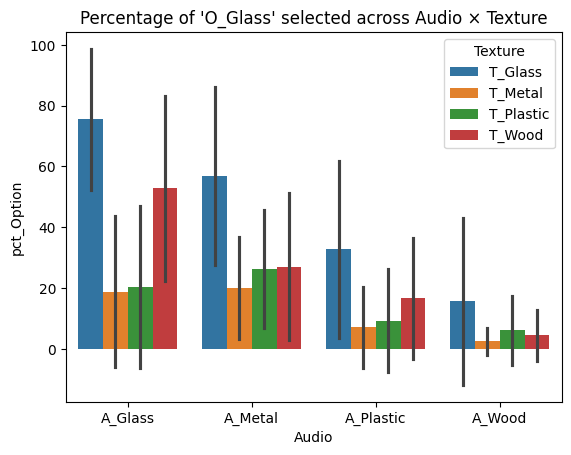

/tmp/ipython-input-372821065.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=subset, x="Audio", y="pct_Option", hue="Texture", ci="sd")


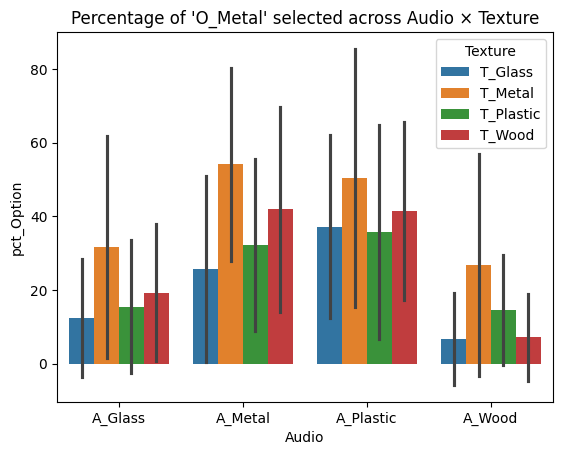

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipython-input-372821065.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=subset, x="Audio", y="pct_Option", hue="Texture", ci="sd")


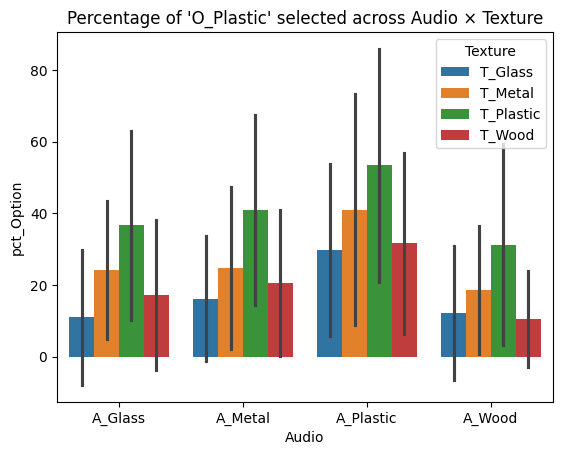

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipython-input-372821065.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=subset, x="Audio", y="pct_Option", hue="Texture", ci="sd")


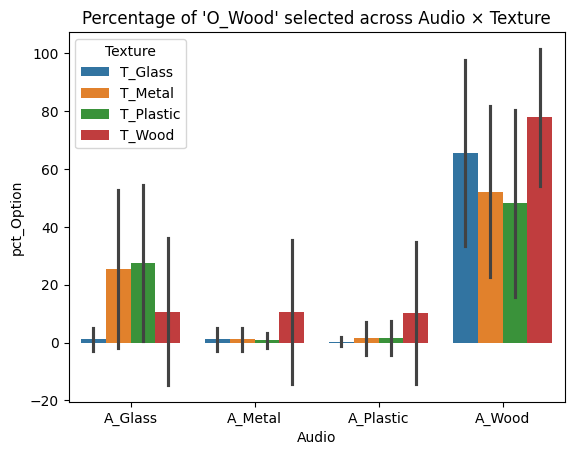

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
results = {}

for opt in df_xform["Option"].unique():
    subset = df_xform[df_xform["Option"] == opt]
    model = smf.mixedlm(
        "pct_Option ~ Audio + Texture",
        data=subset,
        groups=subset["Participant_ID"]
    ).fit(method="powell", maxiter=1000)
    results[opt] = model.summary()
    sns.barplot(data=subset, x="Audio", y="pct_Option", hue="Texture", ci="sd")
    plt.title(f"Percentage of '{opt}' selected across Audio × Texture")
    plt.show()


In [ ]:
#accounting for random intercepts and random slope too
subset = df_xform[df_xform["Option"] == "O_Glass"]
model = smf.mixedlm(
    "pct_Option ~ Audio + Texture + Audio:Texture",
    data=subset,
    groups=subset["Participant_ID"],
    re_formula="~Audio"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())
#results.aic

                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            pct_Option
No. Observations:            672                Method:                        REML      
No. Groups:                  42                 Scale:                         361.5556  
Min. group size:             16                 Log-Likelihood:                -2947.0225
Max. group size:             16                 Converged:                     Yes       
Mean group size:             16.0                                                        
-----------------------------------------------------------------------------------------
                                           Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------------
Intercept                                   75.476    3.693  20.436 0.000  68.237  82.715
Audio[T.A_Metal]                    

# **Exp 1 a/v/n**

In [ ]:
#dataframe after dropping matching condition
import pandas as pd
df_match=pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'match_type', 'match_freq', 'pct_match'])
#print(df_xform)

Target_name = ['Glass', 'Metal', 'Plastic', 'Wood']
Audio_name = ['Glass', 'Metal', 'Plastic', 'Wood']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_a = 0
      count_v = 0
      count_n = 0
      for i in df.index:
        if ((df['Audio Source'][i] == n) & (df['Target'][i] == m)):
          if(df['Option'][i] == n):
            count_a=count_a+1
          if(df['Option'][i] == m):
            count_v=count_v+1
          if((n != df['Option'][i]) & (m != df['Option'][i])):
            count_n=count_n+1
      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
          if (sheet_name2.split('-')[0] == find_part):
            for j in df2.index:
              if ((df['Audio Source'][j] == n) & (df['Target'][j] == m)):
                if (df['Option'][j] == n):
                  count_a=count_a+1
                if (df['Option'][j]== m):
                  count_v=count_v+1
                if ((n != df['Option'][j]) & (m != df['Option'][j])):
                  count_n=count_n+1

      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Audio', count_a, (count_a/20)*100]
      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Video', count_v, (count_v/20)*100]
      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Neither', count_n, (count_n/20)*100]

df_match.drop(df_match[df_match.Texture == df_match.Audio].index, inplace=True)

df_match["Audio"] = "A_" + df_match["Audio"].astype(str)
df_match["Texture"] = "T_" + df_match["Texture"].astype(str)
df_match["match_type"] = "M_" + df_match["match_type"].astype(str)

print(df_match)
df_match.head(5)

     Participant_ID  Texture      Audio         match_type  match_freq  \
126              P1  T_Glass    A_Metal    M_Matches Audio           4   
127              P1  T_Glass    A_Metal    M_Matches Video           8   
128              P1  T_Glass    A_Metal  M_Matches Neither           8   
129              P2  T_Glass    A_Metal    M_Matches Audio           4   
130              P2  T_Glass    A_Metal    M_Matches Video           8   
...             ...      ...        ...                ...         ...   
1885            P51   T_Wood  A_Plastic    M_Matches Video           4   
1886            P51   T_Wood  A_Plastic  M_Matches Neither          14   
1887            P53   T_Wood  A_Plastic    M_Matches Audio           4   
1888            P53   T_Wood  A_Plastic    M_Matches Video           0   
1889            P53   T_Wood  A_Plastic  M_Matches Neither          16   

      pct_match  
126        20.0  
127        40.0  
128        40.0  
129        20.0  
130        40.0  
...

,Participant_ID,Texture,Audio,match_type,match_freq,pct_match
126,P1,T_Glass,A_Metal,M_Matches Audio,4,20.0
127,P1,T_Glass,A_Metal,M_Matches Video,8,40.0
128,P1,T_Glass,A_Metal,M_Matches Neither,8,40.0
129,P2,T_Glass,A_Metal,M_Matches Audio,4,20.0
130,P2,T_Glass,A_Metal,M_Matches Video,8,40.0


In [ ]:
#dataframe keeping matching condition and adding new category
import pandas as pd
df_match=pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'match_type', 'match_freq', 'pct_match'])
#print(df_xform)

Target_name = ['Glass', 'Metal', 'Plastic', 'Wood']
Audio_name = ['Glass', 'Metal', 'Plastic', 'Wood']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_a = 0
      count_v = 0
      count_n = 0
      count_b = 0
      for i in df.index:
        if ((df['Audio Source'][i] == n) & (df['Target'][i] == m)):
          if(df['Audio Source'][i] == df['Target'][i]):
            if (df['Option'][i] == n):
              count_b = count_b + 1
            else:
              count_n = count_n + 1
          else:
            if(df['Option'][i] == n):
              count_a=count_a+1
            if(df['Option'][i] == m):
              count_v=count_v+1
            if((n != df['Option'][i]) & (m != df['Option'][i])):
              count_n=count_n+1
      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
          if (sheet_name2.split('-')[0] == find_part):
            for j in df2.index:
              if ((df2['Audio Source'][j] == n) & (df2['Target'][j] == m)):
                if(df2['Audio Source'][j] == df2['Target'][j]):
                  if (df2['Option'][j] == n):
                    count_b = count_b + 1
                  else:
                   count_n = count_n + 1
                else:
                  if (df2['Option'][j] == n):
                    count_a=count_a+1
                  if (df2['Option'][j]== m):
                    count_v=count_v+1
                  if ((n != df2['Option'][j]) & (m != df2['Option'][j])):
                    count_n=count_n+1

      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Both', count_b, (count_b/20)*100]
      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Audio', count_a, (count_a/20)*100]
      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Video', count_v, (count_v/20)*100]
      df_match.loc[len(df_match.index)] = [find_part, m, n, 'Matches Neither', count_n, (count_n/20)*100]

#df_match.drop(df_match[df_match.Texture == df_match.Audio].index, inplace=True)

df_match["Audio"] = "A_" + df_match["Audio"].astype(str)
df_match["Texture"] = "T_" + df_match["Texture"].astype(str)
df_match["match_type"] = "M_" + df_match["match_type"].astype(str)

print(df_match)
#df_match.head(20)

     Participant_ID  Texture    Audio         match_type  match_freq  \
0                P1  T_Glass  A_Glass     M_Matches Both          13   
1                P1  T_Glass  A_Glass    M_Matches Audio           0   
2                P1  T_Glass  A_Glass    M_Matches Video           0   
3                P1  T_Glass  A_Glass  M_Matches Neither           7   
4                P2  T_Glass  A_Glass     M_Matches Both          12   
...             ...      ...      ...                ...         ...   
2683            P51   T_Wood   A_Wood  M_Matches Neither           1   
2684            P53   T_Wood   A_Wood     M_Matches Both          20   
2685            P53   T_Wood   A_Wood    M_Matches Audio           0   
2686            P53   T_Wood   A_Wood    M_Matches Video           0   
2687            P53   T_Wood   A_Wood  M_Matches Neither           0   

      pct_match  
0          65.0  
1           0.0  
2           0.0  
3          35.0  
4          60.0  
...         ...  
2683     

In [ ]:
# sanity checks - check if the hardcoded 20 is correct when calculating %
tot = df_match.groupby(["Participant_ID", "Texture", "Audio"])["match_freq"].sum()
print(tot.value_counts().head(20))
print(tot[tot != 20].head(50))

#check %s are calculated correctly
print(df_match[df_match["pct_match"] > 100])

match_freq
20    672
Name: count, dtype: int64
Series([], Name: match_freq, dtype: int64)


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
df = df_match.copy()
#df["Condition"] = df["Audio"].astype(str) + ":" + df["Texture"].astype(str)
# Filter for "Glass" as the selected option
df_audio = df[df["match_type"] == "M_Matches Audio"].copy()
df_video = df[df["match_type"] == "M_Matches Video"].copy()
df_neither = df[df["match_type"] == "M_Matches Neither"].copy()
df_both = df[df["match_type"] == "M_Matches Both"].copy()

# Ensure categorical variables
for col in ["Participant_ID", "Texture", "Audio","match_type"]:
    df_audio[col] = df_audio[col].astype("category")

# Fit LMM

model = smf.mixedlm(
    "pct_match ~ C(Audio)*C(Texture)",
    data=df_both,
    groups=df_both["Participant_ID"],
    re_formula="~1"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())
ll = result.llf
k = result.df_modelwc
n = result.nobs
aic = -2 * ll + 2 * k
bic= -2 * ll + np.log(n) * k
print(aic)
print(bic)


                           Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             pct_match 
No. Observations:             672                 Method:                         REML      
No. Groups:                   42                  Scale:                          139.6382  
Min. group size:              16                  Log-Likelihood:                 -2591.8420
Max. group size:              16                  Converged:                      Yes       
Mean group size:              16.0                                                          
--------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------------
Intercept                                      72.976    1.864  39.152 0.000  69.323  76.629
C(Aud

In [ ]:
#instead of adding 'both' category, counting the matching trials twice for matching audio and video gives this:

df_audio_frame = df_match.copy()
df_video_frame = df_match.copy()

# Audio frame: "Both" -> "Matches Audio"
df_audio_frame.loc[df_audio_frame["match_type"] == "M_Matches Both", "match_type"] = "M_Matches Audio"

# Video frame: "Both" -> "Matches Video"
df_video_frame.loc[df_video_frame["match_type"] == "M_Matches Both", "match_type"] = "M_Matches Video"

#remove the extra rows and collapse it such that we have 1 row per participant per coniditon
group_cols = ["Participant_ID", "Texture", "Audio", "match_type"]
df_audio_agg = (df_audio_frame.groupby(group_cols, as_index=False)["match_freq"].sum())
df_audio_agg["pct_match"] = df_audio_agg["match_freq"] / 20 * 100
df_audio = df_audio_agg[df_audio_agg["match_type"] == "M_Matches Audio"]

df_video_agg = (df_video_frame.groupby(group_cols, as_index=False)["match_freq"].sum())
df_video_agg["pct_match"] = df_video_agg["match_freq"] / 20 * 100
df_video = df_video_agg[df_video_agg["match_type"] == "M_Matches Video"]

df_neither = df_match[df_match["match_type"] == "M_Matches Neither"]

model = smf.mixedlm(
    "pct_match ~ C(Audio)*C(Texture)",
    data=df_audio,
    groups=df_audio["Participant_ID"],
    re_formula="~C(Texture)"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())
ll = result.llf
k = result.df_modelwc
n = result.nobs
aic = -2 * ll + 2 * k
bic= -2 * ll + np.log(n) * k
print(aic)
print(bic)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1556: RuntimeWarning: invalid value encountered in log
  likeval -= (self.n_totobs - self.k_fe) * np.log(qf) / 2.


LinAlgError: Eigenvalues did not converge

In [ ]:
#df_match.groupby(["Participant_ID", "Texture", "Audio"]).match_freq.sum().unique()
df_audio.groupby(["Audio","Texture"])["pct_match"].nunique()


/tmp/ipython-input-2254068051.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_audio.groupby(["Audio","Texture"])["pct_match"].nunique()


Audio      Texture  
A_Glass    T_Glass       1
           T_Metal       8
           T_Plastic     9
           T_Wood       10
A_Metal    T_Glass       9
           T_Metal       1
           T_Plastic    10
           T_Wood       11
A_Plastic  T_Glass      10
           T_Metal      11
           T_Plastic     1
           T_Wood       10
A_Wood     T_Glass      10
           T_Metal      10
           T_Plastic    11
           T_Wood        1
Name: pct_match, dtype: int64

# **#--------EXP 2 STUFF-----------------**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#read all csvs
data1 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Glass-N.xlsx', header = 3, sheet_name=None, usecols="A:H")
data2 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Glass-S.xlsx', header = 3, sheet_name=None, usecols="A:H")
data3 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Glass-L.xlsx', header = 3, sheet_name=None, usecols="A:H")
GlassRod_data=[data1, data2, data3]


data4 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Metal-N.xlsx', header = 3, sheet_name=None, usecols="A:H")
data5 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Metal-S.xlsx', header = 3, sheet_name=None, usecols="A:H")
data6 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Metal-L.xlsx', header = 3, sheet_name=None, usecols="A:H")
MetalRod_data=[data4, data5, data6]

data7 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Plastic-N.xlsx', header = 3, sheet_name=None, usecols="A:H")
data8 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Plastic-S.xlsx', header = 3, sheet_name=None, usecols="A:H")
data9 = pd.read_excel(r'/content/drive/MyDrive/data/Follow-up final data/URPP-Plastic-L.xlsx', header = 3, sheet_name=None, usecols="A:H")
PlasticRod_data=[data7, data8, data9]



In [ ]:
#segregate into different noise levels and add to dataframe
search_key1 = '-NN'
search_key2 = '-SN'
search_key3 = '-MN'

#starts with no noise
NN_Glass_N = {}
MN_Glass_N = {}
SN_Glass_N = {}

#starts with some noise
NN_Glass_S = {}
MN_Glass_S = {}
SN_Glass_S = {}

#starts with high noise
NN_Glass_L = {}
MN_Glass_L = {}
SN_Glass_L = {}

# loop through the list of dictionaries and save them into new dictionaries segregated by noise levels
for sheet_name, df in GlassRod_data[0].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Glass_N[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Glass_N[sheet_name]=df
  else:
    MN_Glass_N[sheet_name]=df

for sheet_name, df in GlassRod_data[1].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Glass_S[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Glass_S[sheet_name]=df
  else:
    MN_Glass_S[sheet_name]=df

for sheet_name, df in GlassRod_data[2].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Glass_L[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Glass_L[sheet_name]=df
  else:
    MN_Glass_L[sheet_name]=df

#add all to same dataframe
print(NN_Glass_N.keys())
print(SN_Glass_N.keys())
print(NN_Glass_N.keys())

dict_keys(['Mel-NN', 'Kian-NN', 'Ali-NN', 'Oni-NN', 'Ana-NN', 'Khad-NN'])
dict_keys(['Mel-SN', 'Kian-SN', 'Ali-SN', 'Oni-SN', 'Ana-SN', 'Khad-SN'])
dict_keys(['Mel-NN', 'Kian-NN', 'Ali-NN', 'Oni-NN', 'Ana-NN', 'Khad-NN'])


In [ ]:
#For metal

#segregate into different noise levels and add to dataframe
search_key1 = '-NN'
search_key2 = '-SN'
search_key3 = '-MN'

#starts with no noise
NN_Metal_N = {}
MN_Metal_N = {}
SN_Metal_N = {}

#starts with some noise
NN_Metal_S = {}
MN_Metal_S = {}
SN_Metal_S = {}

#starts with high noise
NN_Metal_L = {}
MN_Metal_L = {}
SN_Metal_L = {}

# loop through the list of dictionaries and save them into new dictionaries segregated by noise levels
for sheet_name, df in MetalRod_data[0].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Metal_N[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Metal_N[sheet_name]=df
  else:
    MN_Metal_N[sheet_name]=df

for sheet_name, df in MetalRod_data[1].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Metal_S[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Metal_S[sheet_name]=df
  else:
    MN_Metal_S[sheet_name]=df

for sheet_name, df in MetalRod_data[2].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Metal_L[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Metal_L[sheet_name]=df
  else:
    MN_Metal_L[sheet_name]=df

#add all to same dataframe
print(NN_Metal_N.keys())
print(SN_Metal_S.keys())
print(MN_Metal_L.keys())

dict_keys(['Ges-NN', 'Muz-NN', 'Isa-NN', 'Fran-NN', 'Somy-NN', 'Tobe-NN'])
dict_keys(['Dev-SN', 'Aye-SN', 'Wend-SN', 'Mry-SN', 'Son-SN', 'Fel-SN'])
dict_keys(['Maria-MN', 'Dar-MN', 'Suk-MN', 'Moh-MN', 'Jor-MN', 'Tesi-MN'])


In [ ]:
#ForPlastic

#segregate into different noise levels and add to dataframe
search_key1 = '-NN'
search_key2 = '-SN'
search_key3 = '-MN'

#starts with no noise
NN_Plastic_N = {}
MN_Plastic_N = {}
SN_Plastic_N = {}

#starts with some noise
NN_Plastic_S = {}
MN_Plastic_S = {}
SN_Plastic_S = {}

#starts with high noise
NN_Plastic_L = {}
MN_Plastic_L = {}
SN_Plastic_L = {}

# loop through the list of dictionaries and save them into new dictionaries segregated by noise levels
for sheet_name, df in PlasticRod_data[0].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Plastic_N[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Plastic_N[sheet_name]=df
  else:
    MN_Plastic_N[sheet_name]=df

for sheet_name, df in PlasticRod_data[1].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Plastic_S[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Plastic_S[sheet_name]=df
  else:
    MN_Plastic_S[sheet_name]=df

for sheet_name, df in PlasticRod_data[2].items():
  df.drop(df.tail(1).index,inplace=True)
  if search_key1 in sheet_name:
    NN_Plastic_L[sheet_name] = df
  elif search_key2 in sheet_name:
    SN_Plastic_L[sheet_name]=df
  else:
    MN_Plastic_L[sheet_name]=df

#add all to same dataframe
print(NN_Plastic_N.keys())
print(SN_Plastic_S.keys())
print(MN_Plastic_L.keys())

dict_keys(['Chris-NN', 'Hong-NN', 'Jash-NN', 'Kud-NN', 'Xue-NN', 'Diya-NN'])
dict_keys(['Cean-SN', 'Wei-SN', 'Madh-SN', 'Arm-SN', 'Farh-SN', 'Stph-SN'])
dict_keys(['Man-MN', 'Rom-MN', 'Lind-MN', 'Fjr-MN', 'Alis-MN', 'Josh-MN'])


In [ ]:
import pandas as pd
# Create the output dataframe
df_xform = pd.DataFrame(columns=['Participant_ID', 'Rod', 'Noise', 'Order', 'Texture', 'Audio', 'Option', 'pct_Option'])

# Your 8 valid (Target, Audio) conditions
valid_conditions = [
    ("Glass", "Glass"),
    ("Metal", "Metal"),
    ("Plastic", "Plastic"),
    ("Wood", "Wood"),
    ("Metal", "Glass"),
    ("Plastic", "Metal"),
    ("Wood", "Plastic"),
    ("Glass", "Wood"),
]

# Loop through each valid condition
for target, audio in valid_conditions:
    for sheet_name, df in NN_Glass_N.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Glass_N.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Glass_N.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]


# Loop through each valid condition - for metal now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Metal_N.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Metal_N.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Metal_N.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

# Loop through each valid condition - for Plastic now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Plastic_N.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Plastic_N.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Plastic_N.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Wood', (count_w/10)*100]

#now this loop is for 'starts with S'

# Loop through each valid condition
for target, audio in valid_conditions:
    for sheet_name, df in NN_Glass_S.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Glass_S.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Glass_S.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]


# Loop through each valid condition - for metal now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Metal_S.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Metal_S.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Metal_S.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

# Loop through each valid condition - for Plastic now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Plastic_S.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Plastic_S.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Plastic_S.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Wood', (count_w/10)*100]

#now this loop is for 'starts with M'

# Loop through each valid condition
for target, audio in valid_conditions:
    for sheet_name, df in NN_Glass_L.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Glass_L.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Glass_L.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]


# Loop through each valid condition - for metal now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Metal_L.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Metal_L.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Metal_L.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

# Loop through each valid condition - for Plastic now
for target, audio in valid_conditions:
    for sheet_name, df in NN_Plastic_L.items():
        find_part = sheet_name.split('-')[0]
        count_g = count_m = count_p = count_w = 0

        for i in df.index:
            if df.loc[i, 'Audio Source'] == audio and df.loc[i, 'Target'] == target:
                if df.loc[i, 'Option'] == 'Glass': count_g += 1
                if df.loc[i, 'Option'] == 'Metal': count_m += 1
                if df.loc[i, 'Option'] == 'Plastic': count_p += 1
                if df.loc[i, 'Option'] == 'Wood': count_w += 1

        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
        df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for SN
        for sheet_name2, df2 in SN_Plastic_L.items():
            if sheet_name2.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for j in df2.index:
                    if df2.loc[j, 'Audio Source'] == audio and df2.loc[j, 'Target'] == target:
                        if df2.loc[j, 'Option'] == 'Glass': count_g += 1
                        if df2.loc[j, 'Option'] == 'Metal': count_m += 1
                        if df2.loc[j, 'Option'] == 'Plastic': count_p += 1
                        if df2.loc[j, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]

        # Repeat for MN
        for sheet_name3, df3 in MN_Plastic_L.items():
            if sheet_name3.split('-')[0] == find_part:
                count_g = count_m = count_p = count_w = 0
                for k in df3.index:
                    if df3.loc[k, 'Audio Source'] == audio and df3.loc[k, 'Target'] == target:
                        if df3.loc[k, 'Option'] == 'Glass': count_g += 1
                        if df3.loc[k, 'Option'] == 'Metal': count_m += 1
                        if df3.loc[k, 'Option'] == 'Plastic': count_p += 1
                        if df3.loc[k, 'Option'] == 'Wood': count_w += 1
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Glass', (count_g/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Metal', (count_m/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Plastic', (count_p/10)*100]
                df_xform.loc[len(df_xform.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Wood', (count_w/10)*100]



# Save the result
df_xform.to_csv('filtered3_output.csv', index=False)
print(df_xform)


     Participant_ID      Rod Noise          Order Texture  Audio   Option  \
0               Mel    Glass    NN  Starts with N   Glass  Glass    Glass   
1               Mel    Glass    NN  Starts with N   Glass  Glass    Metal   
2               Mel    Glass    NN  Starts with N   Glass  Glass  Plastic   
3               Mel    Glass    NN  Starts with N   Glass  Glass     Wood   
4               Mel    Glass    SN  Starts with N   Glass  Glass    Glass   
...             ...      ...   ...            ...     ...    ...      ...   
5179           Josh  Plastic    SN  Starts with M   Glass   Wood     Wood   
5180           Josh  Plastic    MN  Starts with M   Glass   Wood    Glass   
5181           Josh  Plastic    MN  Starts with M   Glass   Wood    Metal   
5182           Josh  Plastic    MN  Starts with M   Glass   Wood  Plastic   
5183           Josh  Plastic    MN  Starts with M   Glass   Wood     Wood   

      pct_Option  
0           70.0  
1           30.0  
2            0.0  

In [ ]:
data = df_xform.copy()
print(data)


     Participant_ID      Rod Noise          Order Texture  Audio   Option  \
0               Mel    Glass    NN  Starts with N   Glass  Glass    Glass   
1               Mel    Glass    NN  Starts with N   Glass  Glass    Metal   
2               Mel    Glass    NN  Starts with N   Glass  Glass  Plastic   
3               Mel    Glass    NN  Starts with N   Glass  Glass     Wood   
4               Mel    Glass    SN  Starts with N   Glass  Glass    Glass   
...             ...      ...   ...            ...     ...    ...      ...   
5179           Josh  Plastic    SN  Starts with M   Glass   Wood     Wood   
5180           Josh  Plastic    MN  Starts with M   Glass   Wood    Glass   
5181           Josh  Plastic    MN  Starts with M   Glass   Wood    Metal   
5182           Josh  Plastic    MN  Starts with M   Glass   Wood  Plastic   
5183           Josh  Plastic    MN  Starts with M   Glass   Wood     Wood   

      pct_Option  
0           70.0  
1           30.0  
2            0.0  

# **Charts for exp2**

     Participant_ID      Rod Noise          Order Texture  Audio   Option  \
0               Mel    Glass    NN  Starts with N   Glass  Glass    Glass   
1               Mel    Glass    NN  Starts with N   Glass  Glass    Metal   
2               Mel    Glass    NN  Starts with N   Glass  Glass  Plastic   
3               Mel    Glass    NN  Starts with N   Glass  Glass     Wood   
4               Mel    Glass    SN  Starts with N   Glass  Glass    Glass   
...             ...      ...   ...            ...     ...    ...      ...   
5179           Josh  Plastic    SN  Starts with M   Glass   Wood     Wood   
5180           Josh  Plastic    MN  Starts with M   Glass   Wood    Glass   
5181           Josh  Plastic    MN  Starts with M   Glass   Wood    Metal   
5182           Josh  Plastic    MN  Starts with M   Glass   Wood  Plastic   
5183           Josh  Plastic    MN  Starts with M   Glass   Wood     Wood   

      pct_Option    Condition  
0           70.0  Glass_Glass  
1          

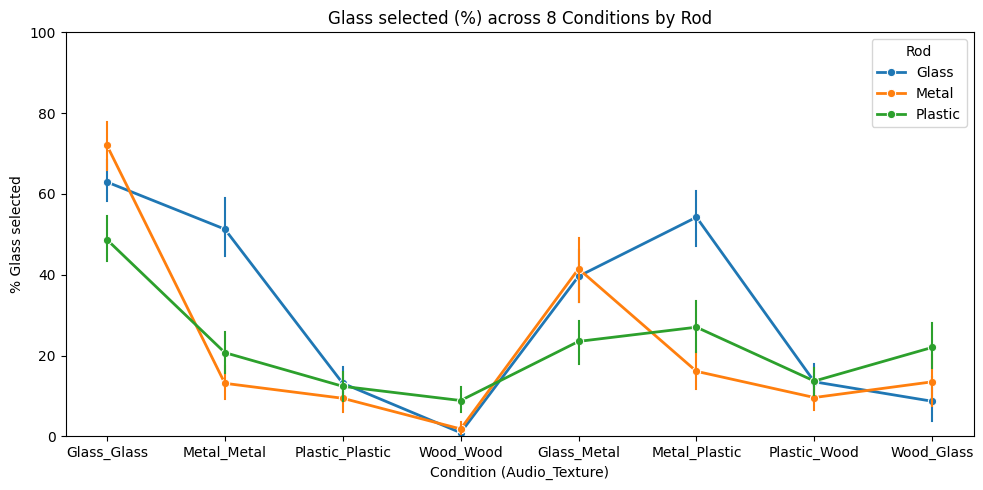

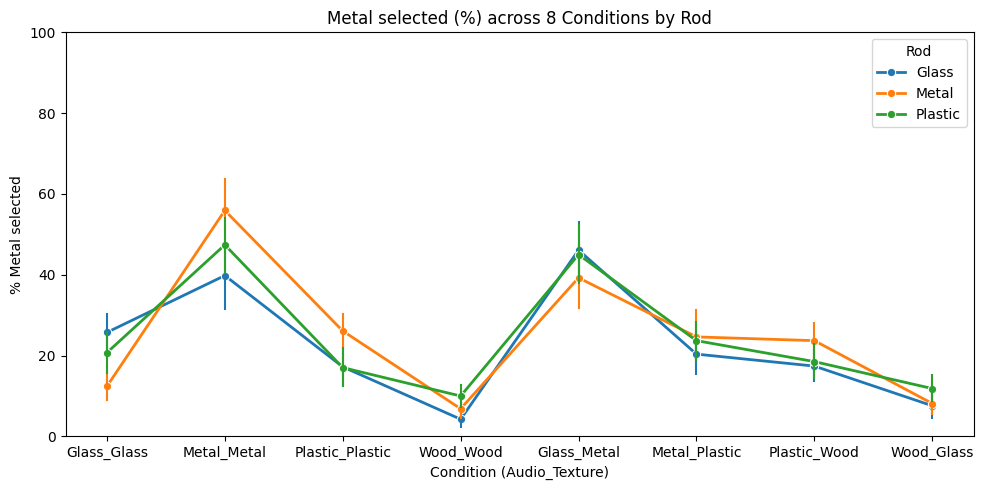

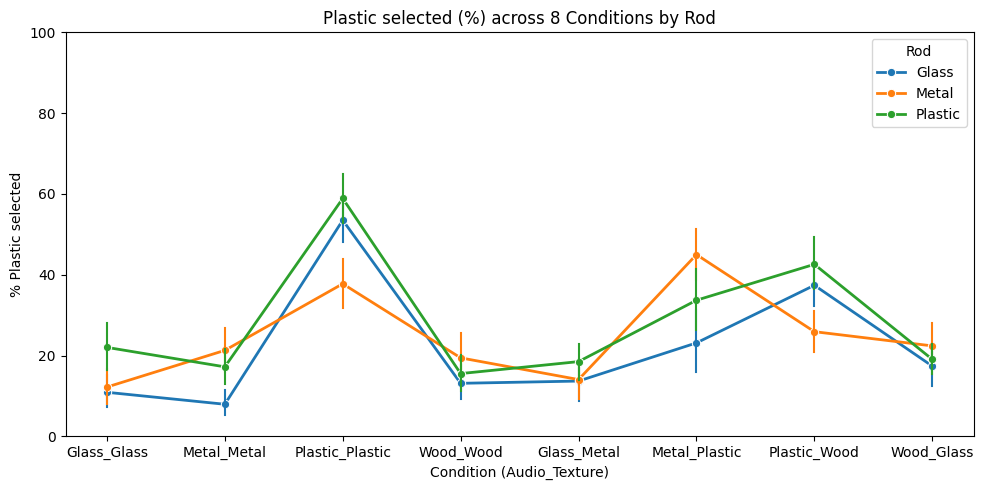

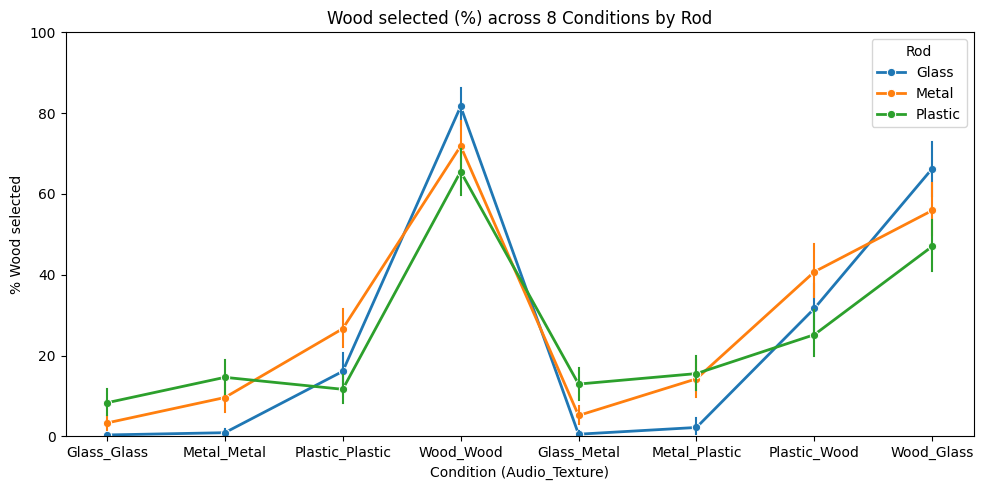

In [ ]:
data["Condition"] = data["Audio"].astype(str) + "_" + data["Texture"].astype(str)
print(data)
df = data[data["Option"] == "Glass"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Glass selected (%) across 8 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Glass selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Glass across conditions per rod.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Metal"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Metal selected (%) across 8 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Metal selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Metal across conditions per rod.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Plastic"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Plastic selected (%) across 8 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Plastic selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Plastic across conditions per rod.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Wood"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)

plt.title("Wood selected (%) across 8 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Wood selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Wood across conditions per rod.png', bbox_inches='tight')
plt.show()

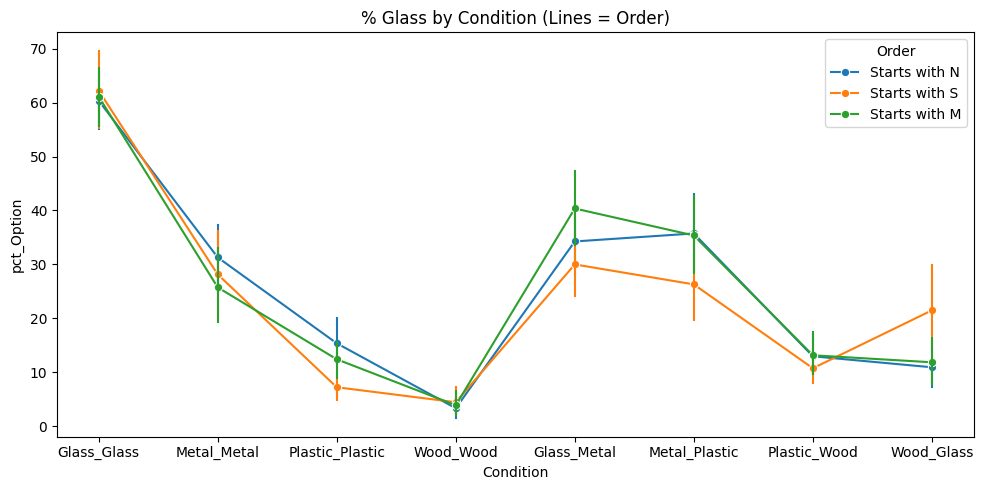

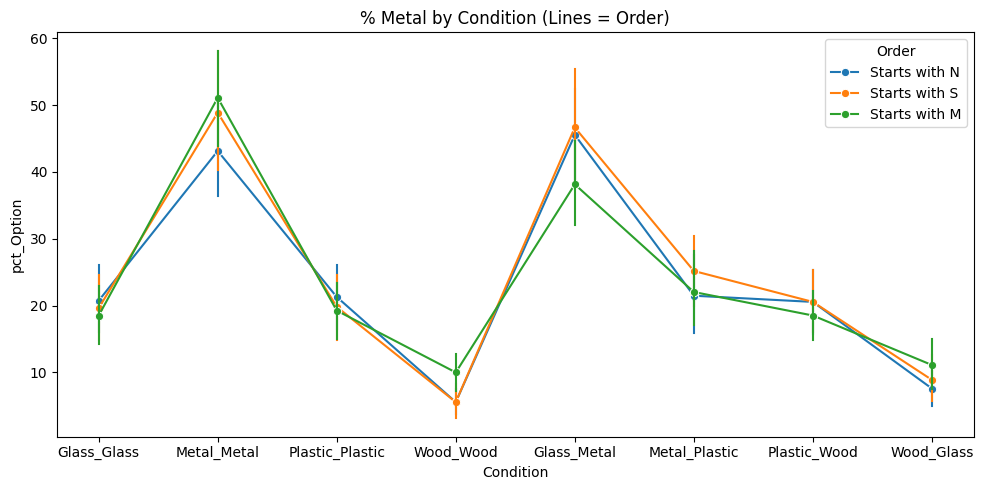

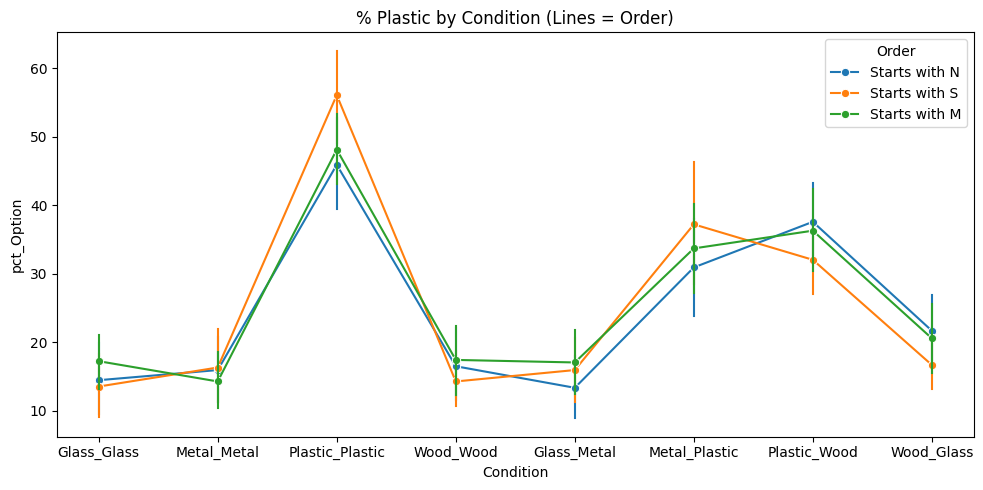

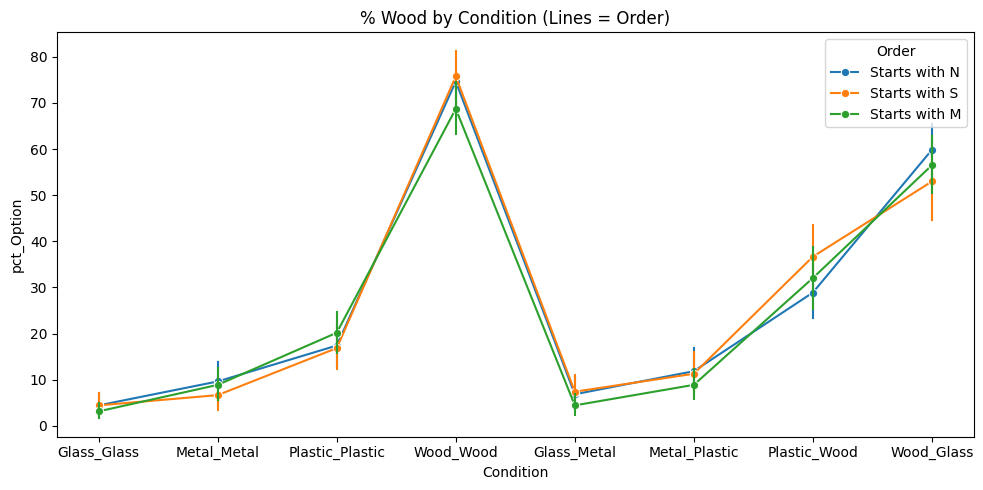

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for glass only
df = data[data["Option"] == "Glass"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Glass by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Glass across conditions by Order.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Metal"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Metal by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Metal across conditions by Order.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Plastic"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Plastic by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Plastic across conditions by Order.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Wood"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Wood by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Wood across conditions by Order.png', bbox_inches='tight')
plt.show()

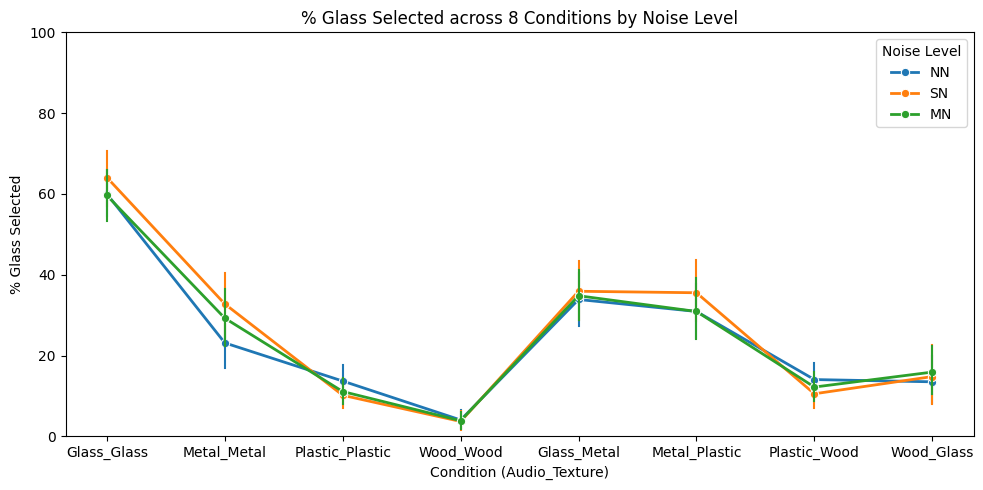

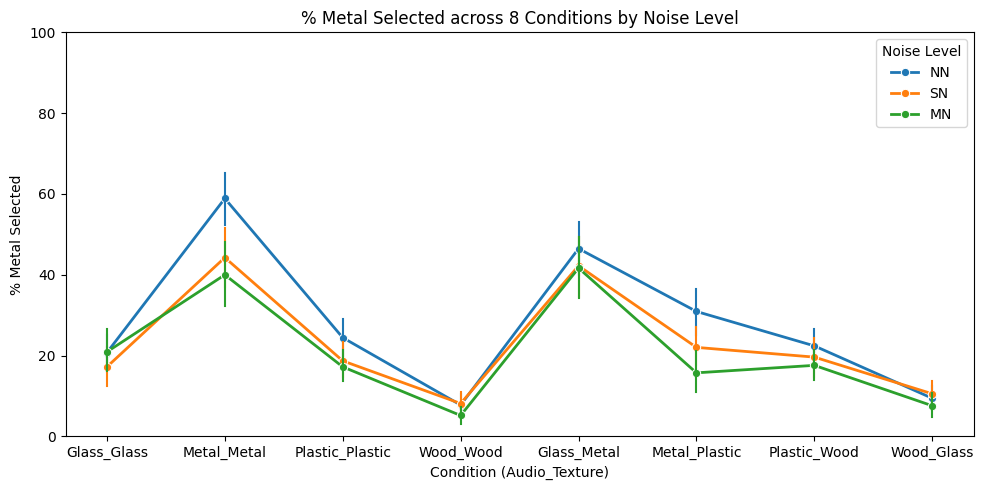

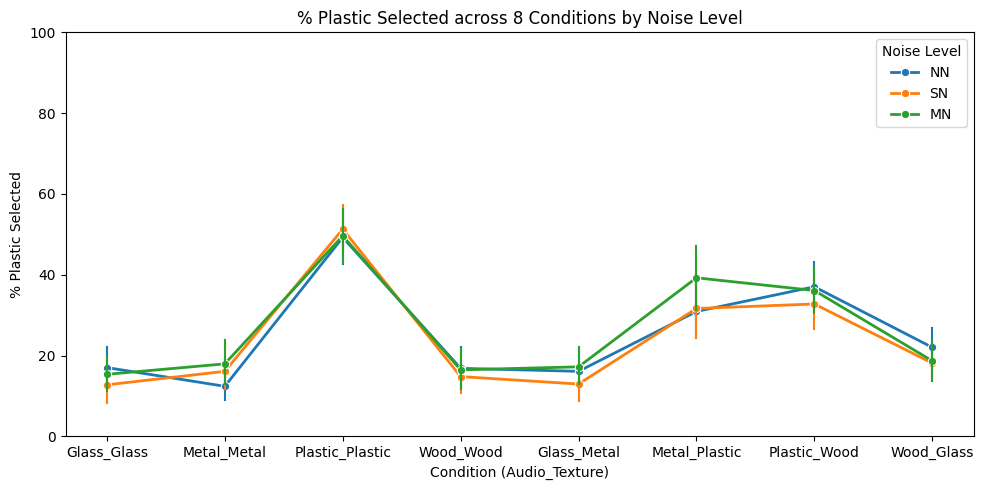

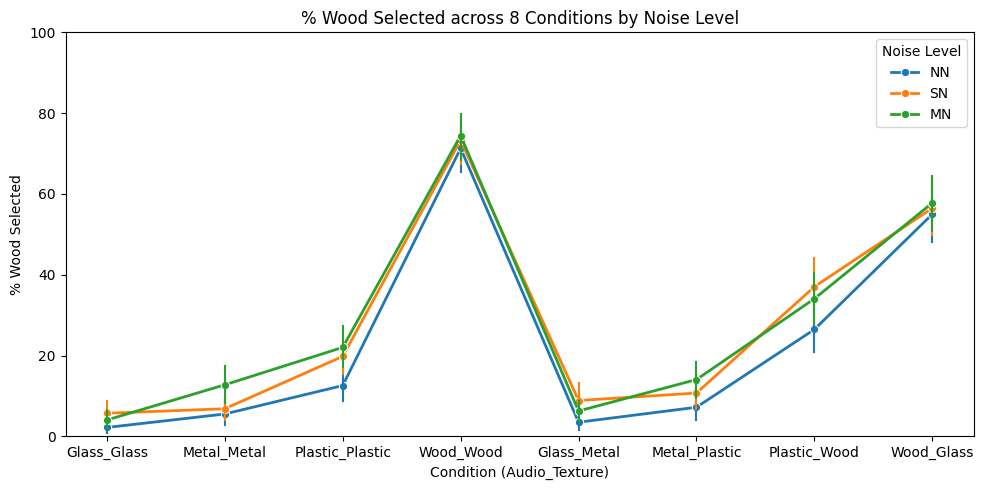

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Glass
df = data[data["Option"] == "Glass"].copy()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",        # No confidence interval shading
    linewidth=2
)

plt.title("% Glass Selected across 8 Conditions by Noise Level")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Glass Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Glass_across_conditions_by_noise.png', bbox_inches='tight')
plt.show()


df = data[data["Option"] == "Metal"].copy()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",        # No confidence interval shading
    linewidth=2
)

plt.title("% Metal Selected across 8 Conditions by Noise Level")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Metal Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Metal_across_conditions_by_noise.png', bbox_inches='tight')
plt.show()


df = data[data["Option"] == "Plastic"].copy()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",        # No confidence interval shading
    linewidth=2
)

plt.title("% Plastic Selected across 8 Conditions by Noise Level")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Plastic Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Plastic_across_conditions_by_noise.png', bbox_inches='tight')
plt.show()


df = data[data["Option"] == "Wood"].copy()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",        # No confidence interval shading
    linewidth=2
)

plt.title("% Wood Selected across 8 Conditions by Noise Level")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Wood_across_conditions_by_noise.png', bbox_inches='tight')
plt.show()

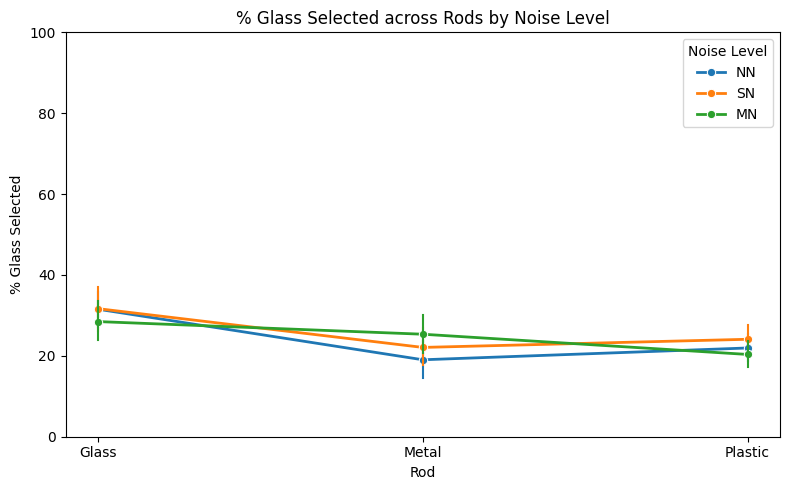

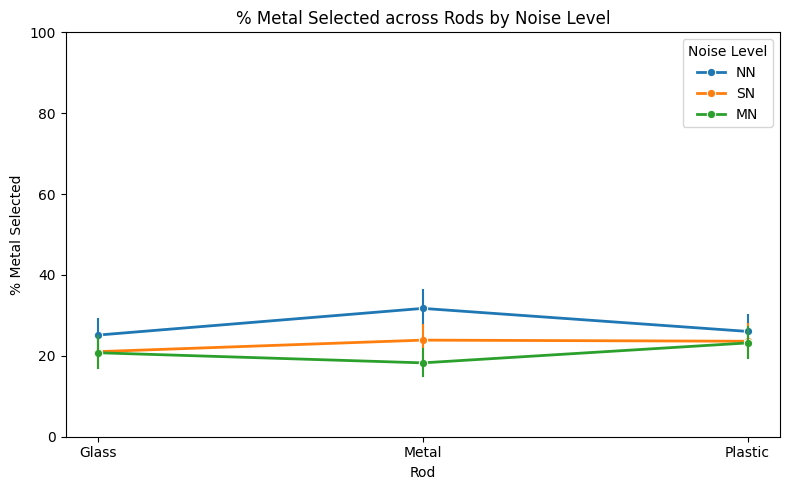

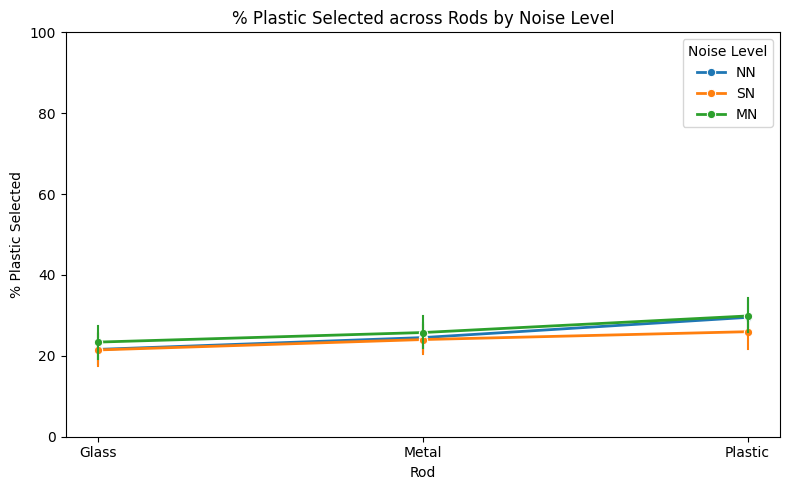

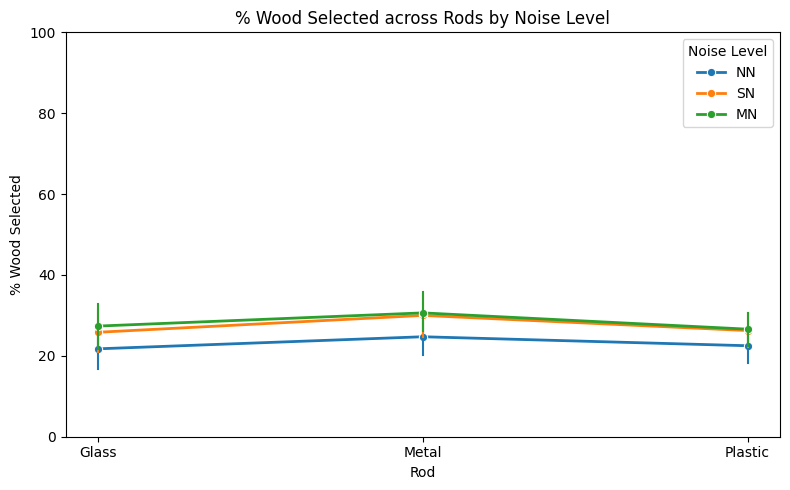

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Glass
df = data[data["Option"] == "Glass"].copy()
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x="Rod",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",          # No CI shading
    linewidth=2
)
plt.title("% Glass Selected across Rods by Noise Level")
plt.ylabel("% Glass Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Glass_by_Rod_and_Noise.png', bbox_inches='tight')
plt.show()


df = data[data["Option"] == "Metal"].copy()
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x="Rod",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",          # No CI shading
    linewidth=2
)
plt.title("% Metal Selected across Rods by Noise Level")
plt.ylabel("% Metal Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Metal_by_Rod_and_Noise.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Plastic"].copy()
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x="Rod",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",          # No CI shading
    linewidth=2
)
plt.title("% Plastic Selected across Rods by Noise Level")
plt.ylabel("% Plastic Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Plastic_by_Rod_and_Noise.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Wood"].copy()
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x="Rod",
    y="pct_Option",
    hue="Noise",       # Each Noise level is a separate line
    marker="o",
    err_style="bars",          # No CI shading
    linewidth=2
)
plt.title("% Wood Selected across Rods by Noise Level")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.legend(title="Noise Level")
plt.tight_layout()
plt.savefig('%Wood_by_Rod_and_Noise.png', bbox_inches='tight')
plt.show()

/tmp/ipython-input-449849415.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


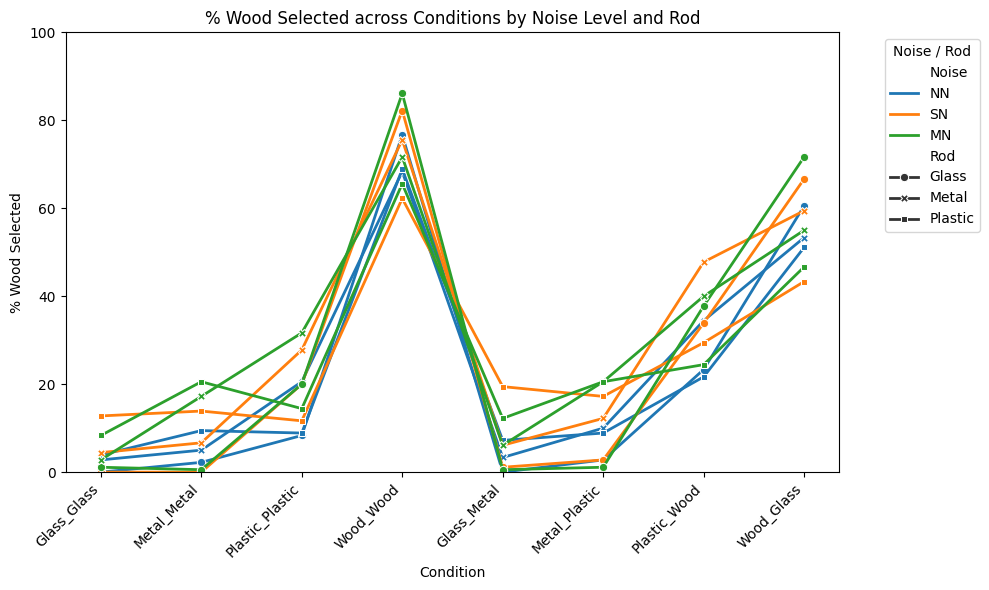

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Wood
df = data[data["Option"] == "Wood"].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_Option",
    hue="Noise",       # Color by Noise level
    style="Rod",       # Different line/marker style for each Rod
    markers=True,
    dashes=False,      # Solid lines for clarity
    ci=None,
    linewidth=2
)

plt.title("% Wood Selected across Conditions by Noise Level and Rod")
plt.xlabel("Condition")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Noise / Rod", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('%Wood_Condition_Noise_Rod.png', bbox_inches='tight')
plt.show()

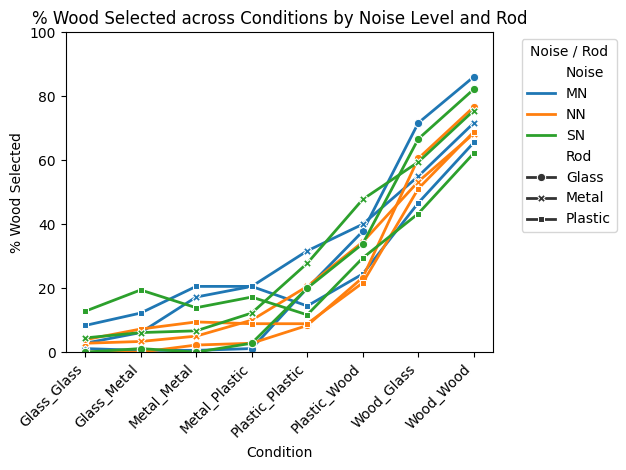

In [ ]:
df_agg = (
    df.groupby(["Condition", "Noise", "Rod"], as_index=False)["pct_Option"]
      .mean()
)

sns.lineplot(
    data=df_agg,
    x="Condition",
    y="pct_Option",
    hue="Noise",
    style="Rod",
    markers=True,
    dashes=False,
    linewidth=2
)

plt.title("% Wood Selected across Conditions by Noise Level and Rod")
plt.xlabel("Condition")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Noise / Rod", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('%Wood_Condition_Noise_Rod.png', bbox_inches='tight')
plt.show()

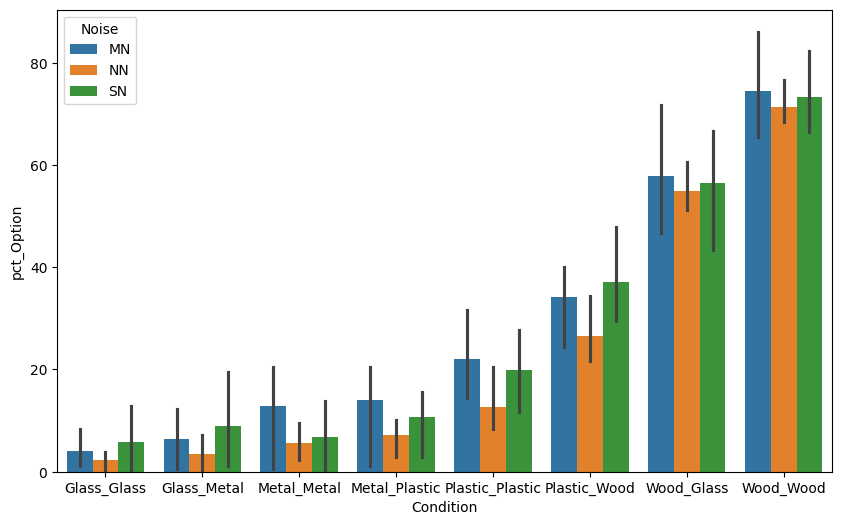

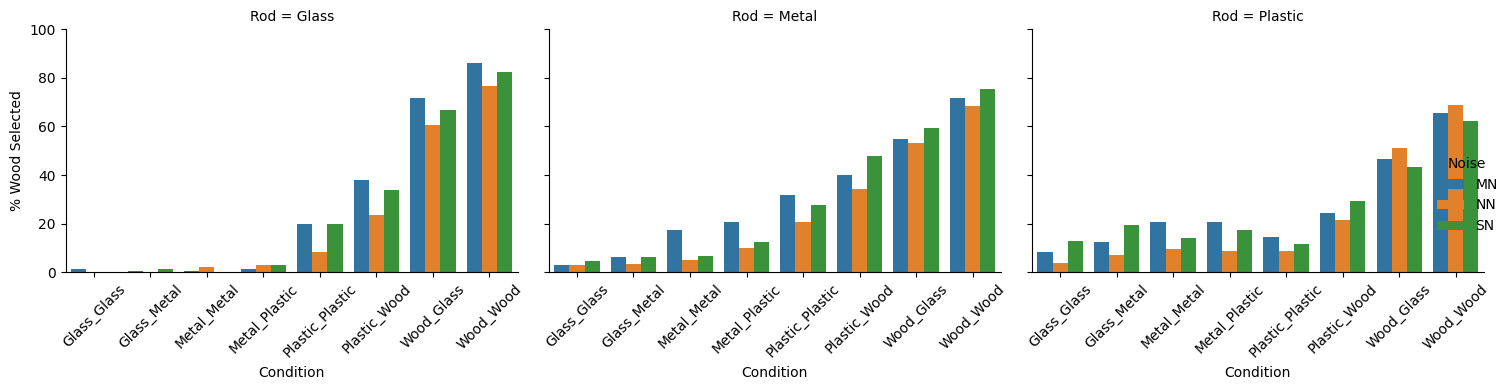

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Wood
df = data[data["Option"] == "Wood"].copy()

# Aggregate to get mean % for each combination
df_agg = (
    df.groupby(["Condition", "Noise", "Rod"], as_index=False)["pct_Option"]
      .mean()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_agg,
    x="Condition",
    y="pct_Option",
    hue="Noise",        # Color = noise level
    dodge=True
)

# Add Rod info as facet subplots for clarity
g = sns.catplot(
    data=df_agg,
    x="Condition",
    y="pct_Option",
    hue="Noise",
    col="Rod",          # Each Rod in its own subplot
    kind="bar",
    height=4,
    aspect=1.2,
    dodge=True
)

g.set_axis_labels("Condition", "% Wood Selected")
g.set_titles("Rod = {col_name}")
g.set(ylim=(0, 100))
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

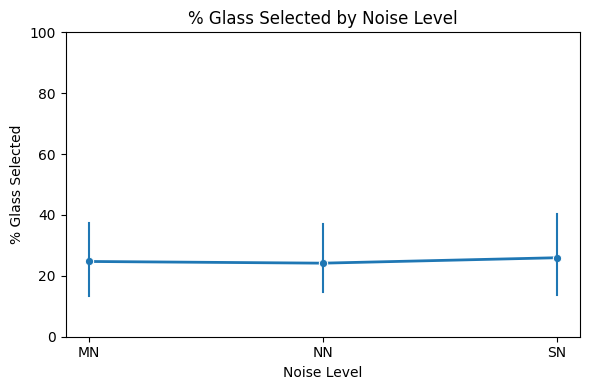

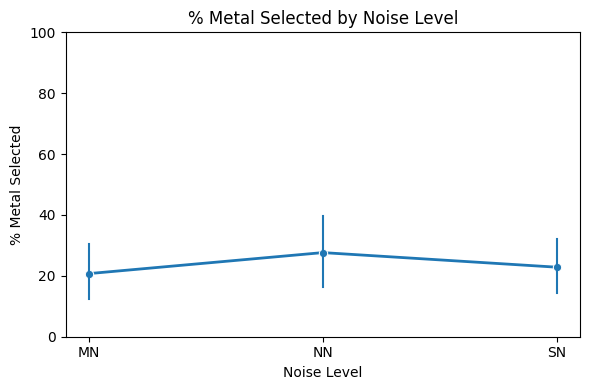

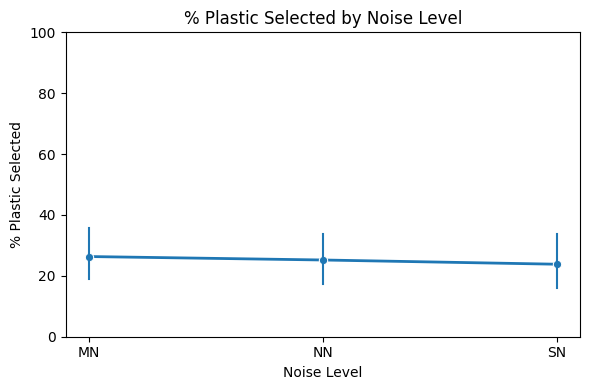

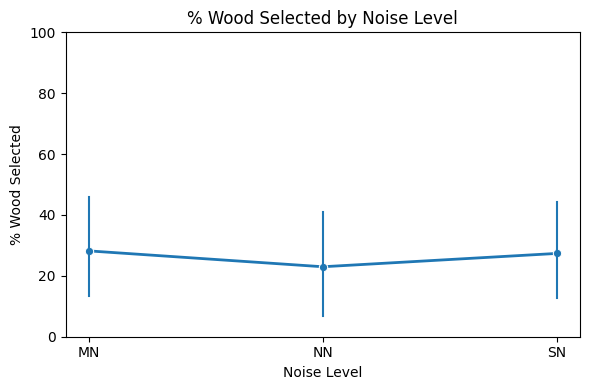

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#plot_order = ['NN', 'SN', 'MN']

# Filter for Glass
df = data[data["Option"] == "Glass"].copy()
df_agg = (
    df.groupby(["Condition", "Noise"], as_index=False)["pct_Option"]
      .mean()
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_agg,
    x="Noise",
    y="pct_Option",
    marker="o",
    err_style="bars",
    linewidth=2,
    #order=plot_order
)

plt.ylabel("% Glass Selected")
plt.xlabel("Noise Level")
plt.title("% Glass Selected by Noise Level")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('Main_effect_Noise on %Glass.png', bbox_inches='tight')
plt.show()

# Filter for Metal
df = data[data["Option"] == "Metal"].copy()
df_agg = (
    df.groupby(["Condition", "Noise"], as_index=False)["pct_Option"]
      .mean()
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_agg,
    x="Noise",
    y="pct_Option",
    marker="o",
    err_style="bars",
    linewidth=2
)

plt.ylabel("% Metal Selected")
plt.xlabel("Noise Level")
plt.title("% Metal Selected by Noise Level")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('Main_effect_Noise on %Metal.png', bbox_inches='tight')
plt.show()

# Filter for Plastic
df = data[data["Option"] == "Plastic"].copy()
df_agg = (
    df.groupby(["Condition", "Noise"], as_index=False)["pct_Option"]
      .mean()
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_agg,
    x="Noise",
    y="pct_Option",
    marker="o",
    err_style="bars",
    linewidth=2
)

plt.ylabel("% Plastic Selected")
plt.xlabel("Noise Level")
plt.title("% Plastic Selected by Noise Level")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('Main_effect_Noise on %Plastic.png', bbox_inches='tight')
plt.show()


# Filter for Wood
df = data[data["Option"] == "Wood"].copy()
df_agg = (
    df.groupby(["Condition", "Noise"], as_index=False)["pct_Option"]
      .mean()
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_agg,
    x="Noise",
    y="pct_Option",
    marker="o",
    err_style="bars",
    linewidth=2
)

plt.ylabel("% Wood Selected")
plt.xlabel("Noise Level")
plt.title("% Wood Selected by Noise Level")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('Main_effect_Noise on %Wood.png', bbox_inches='tight')
plt.show()



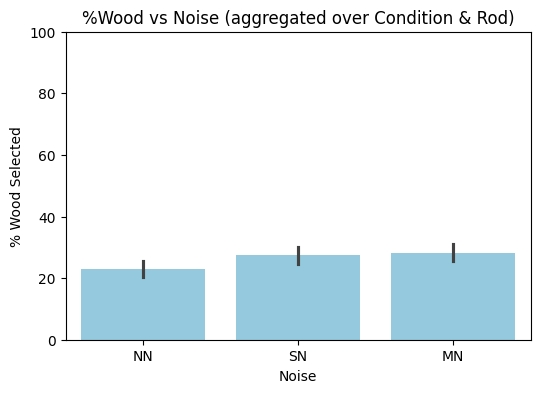

/tmp/ipython-input-3812526274.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


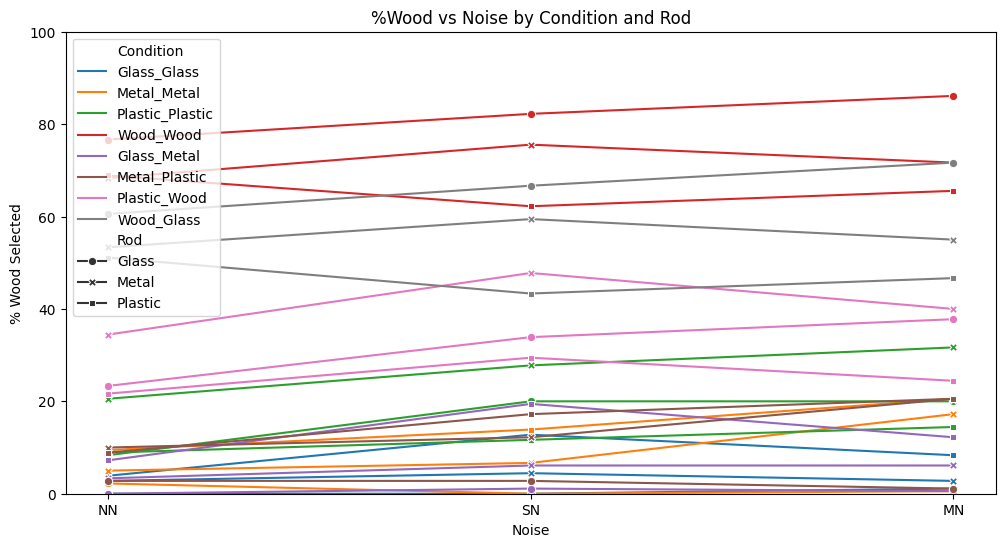

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Simple plot: %Wood vs Noise (ignore Condition & Rod)
plt.figure(figsize=(6,4))
sns.barplot(data= data[data["Option"] == "Wood"], x="Noise", y="pct_Option", color="skyblue")
plt.title("%Wood vs Noise (aggregated over Condition & Rod)")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.show()

# 2) Detailed plot: %Wood vs Noise, broken down by Condition & Rod
plt.figure(figsize=(12,6))
sns.lineplot(
    data=data[data["Option"] == "Wood"],
    x="Noise", y="pct_Option",
    hue="Condition", style="Rod", ci = None,
    markers=True, dashes=False
)
plt.title("%Wood vs Noise by Condition and Rod")
plt.ylabel("% Wood Selected")
plt.ylim(0, 100)
plt.savefig('%Wood.png', bbox_inches='tight')
plt.show()

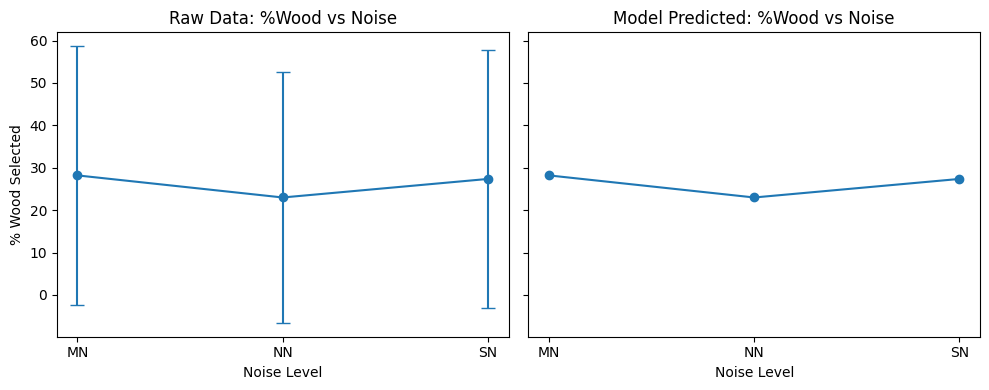

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = data[data["Option"] == "Wood"].copy()
# === 1. Fit your full model ===
model_full = smf.mixedlm(
    "pct_Option ~ Condition * Rod + Noise",
    data=df,
    groups=df["Participant_ID"]  # change if grouping variable differs
).fit()

# === 2. Prepare data for predictions ===
# Create all combinations of Condition, Rod, Noise
pred_df = df[['Condition', 'Rod', 'Noise']].drop_duplicates()
# Average over Condition & Rod for each Noise level
pred_df['pct_Option_pred'] = model_full.predict(pred_df)
pred_mean = pred_df.groupby('Noise')['pct_Option_pred'].mean().reset_index()

# === 3. Get raw aggregated means for comparison ===
raw_mean = df.groupby('Noise')['pct_Option'].mean().reset_index()

# === 4. Plot side-by-side ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Raw data plot
axes[0].errorbar(raw_mean['Noise'], raw_mean['pct_Option'],
                 yerr=df.groupby('Noise')['pct_Option'].std().values,
                 fmt='o-', capsize=5)
axes[0].set_title("Raw Data: %Wood vs Noise")
axes[0].set_xlabel("Noise Level")
axes[0].set_ylabel("% Wood Selected")

# Model predictions plot
axes[1].plot(pred_mean['Noise'], pred_mean['pct_Option_pred'], 'o-')
axes[1].set_title("Model Predicted: %Wood vs Noise")
axes[1].set_xlabel("Noise Level")

plt.tight_layout()
plt.show()


# **LMMs for exp 2**

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

df = df_xform.copy()

# Filter for "Glass" as the selected option
df_glass = df[df["Option"] == "Glass"].copy()

# Ensure categorical variables
for col in ["Participant_ID", "Noise", "Texture", "Audio", "Rod", "Order"]:
    df_glass[col] = df_glass[col].astype("category")

# Fit LMM
model = smf.mixedlm(
    "pct_Option ~ Audio + Texture",
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    pct_Option
No. Observations:    1296       Method:                REML      
No. Groups:          54         Scale:                 428.3135  
Min. group size:     24         Log-Likelihood:        -5777.8127
Max. group size:     24         Converged:             Yes       
Mean group size:     24.0                                        
-----------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept           59.884    1.677  35.710 0.000  56.598  63.171
Audio[T.Metal]      -9.182    1.991  -4.611 0.000 -13.085  -5.279
Audio[T.Plastic]   -32.685    2.300 -14.214 0.000 -37.192 -28.178
Audio[T.Wood]      -43.781    1.991 -21.984 0.000 -47.684 -39.878
Texture[T.Metal]   -23.657    1.991 -11.879 0.000 -27.561 -19.754
Texture[T.Plastic] -16.8

In [ ]:
#since i cant do this with interactions - because audio and video give me 16 combos but i only tested 8, there are gaps/missing stuff that the model cant interpret
#combine audio X texture into a common condition then do the interactions for rod, noise, order

import pandas as pd
import statsmodels.formula.api as smf

# Start from df_xform filtered for 'Glass'
df = df_xform[df_xform["Option"] == "Glass"].copy()

# Make Condition variable
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")

# Ensure other variables are categorical
for col in ["Participant_ID", "Noise", "Rod", "Order"]:
    df[col] = df[col].astype("category")


In [ ]:

# Fit the model: condition × noise × rod × order
model = smf.mixedlm(
    "pct_Option ~ Condition * Noise * Rod * Order",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())
with open("lmm_summary_output.txt", "w") as f:
    f.write(result.summary().as_text())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[(results_df["p_value"] < 0.05)]

# Show result
print(significant_interactions)

                                            Mixed Linear Model Regression Results
Model:                                   MixedLM                        Dependent Variable:                        pct_Option
No. Observations:                        1296                           Method:                                    REML      
No. Groups:                              54                             Scale:                                     359.1392  
Min. group size:                         24                             Log-Likelihood:                            -4920.8563
Max. group size:                         24                             Converged:                                 Yes       
Mean group size:                         24.0                                                                                
-----------------------------------------------------------------------------------------------------------------------------
                                    

In [ ]:

# Fit the model: condition × noise × rod × order
model = smf.mixedlm(
    "pct_Option ~ Noise * Rod * Order + Audio * Noise +Audio * Rod + Audio * Order + Texture * Noise + Texture * Rod + Texture * Order",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())
with open("lmm_summary_output.txt", "w") as f:
    f.write(result.summary().as_text())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[(results_df["p_value"] < 0.05)]

# Show result
print(significant_interactions)

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              pct_Option
No. Observations:               1296                 Method:                          REML      
No. Groups:                     54                   Scale:                           344.3486  
Min. group size:                24                   Log-Likelihood:                  -5472.9664
Max. group size:                24                   Converged:                       Yes       
Mean group size:                24.0                                                            
------------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------------------
Intercept                                          59.776   

In [ ]:
#pct_Option ~ Noise * Audio * Texture

model = smf.mixedlm(
    "pct_Option ~ Noise + Audio + Texture + Noise:Audio + Noise:Texture",  # same as: Noise + Audio + Noise:Audio
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())

#So noise made no significant impact on glass %

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        pct_Option
No. Observations:        1296           Method:                    REML      
No. Groups:              54             Scale:                     429.2469  
Min. group size:         24             Log-Likelihood:            -5743.0162
Max. group size:         24             Converged:                 Yes       
Mean group size:         24.0                                                
-----------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------
Intercept                       58.380    2.730  21.384 0.000  53.029  63.731
Noise[T.NN]                      0.556    3.730   0.149 0.882  -6.755   7.866
Noise[T.SN]                      3.958    3.730   1.061 0.289  -3.352  11.268
Audio[

In [ ]:
#pct_Option ~ Rod * Audio * Texture

model = smf.mixedlm(
    "pct_Option ~ Rod + Audio + Texture + Rod:Audio + Rod:Texture",  # same as: Noise + Audio + Noise:Audio
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[
    (results_df["term"].str.contains(":")) & (results_df["p_value"] < 0.05)
]

# Show result
print(significant_interactions)

                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         pct_Option
No. Observations:         1296            Method:                     REML      
No. Groups:               54              Scale:                      352.1847  
Min. group size:          24              Log-Likelihood:             -5610.6785
Max. group size:          24              Converged:                  Yes       
Mean group size:          24.0                                                  
--------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                          61.435    2.560  24.002 0.000  56.419  66.452
Rod[T.Metal]                        8.634    3.620   2.385 0.017   1.540  15.729
Rod[T.Plastic]                    -13.287    3.620

In [ ]:
model = smf.mixedlm(
    "pct_Option ~ Order + Audio + Texture + Order:Audio + Order:Texture",
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[
    (results_df["term"].str.contains(":")) & (results_df["p_value"] < 0.05)
]

# Show result
print(significant_interactions)

                         Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           pct_Option
No. Observations:             1296              Method:                       REML      
No. Groups:                   54                Scale:                        423.4064  
Min. group size:              24                Log-Likelihood:               -5734.3247
Max. group size:              24                Converged:                    Yes       
Mean group size:              24.0                                                      
----------------------------------------------------------------------------------------
                                           Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------------------
Intercept                                  60.810    2.903  20.946 0.000  55.120  66.500
Order[T.Starts with N]                     -2.5

In [ ]:
model = smf.mixedlm(
    "pct_Option ~ Rod * Audio",
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[
    (results_df["term"].str.contains(":")) & (results_df["p_value"] < 0.05)
]

# Show result
print(significant_interactions)

                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        pct_Option
No. Observations:         1296           Method:                    REML      
No. Groups:               54             Scale:                     402.9721  
Min. group size:          24             Log-Likelihood:            -5715.9766
Max. group size:          24             Converged:                 Yes       
Mean group size:          24.0                                                
------------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------------------
Intercept                        51.296    2.111  24.294 0.000  47.158  55.435
Rod[T.Metal]                      5.463    2.986   1.830 0.067  -0.390  11.315
Rod[T.Plastic]                  -15.185    2.986  -5.085 0.000 -21.038  -

In [ ]:
model = smf.mixedlm(
    "pct_Option ~ Rod * Texture",
    data=df_glass,
    groups=df_glass["Participant_ID"],
    re_formula="~1"
)
result = model.fit(method="powell", maxiter=1000)
print(result.summary())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[
    (results_df["term"].str.contains(":")) & (results_df["p_value"] < 0.05)
]

# Show result
print(significant_interactions)


                     Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        pct_Option
No. Observations:          1296           Method:                    REML      
No. Groups:                54             Scale:                     571.0625  
Min. group size:           24             Log-Likelihood:            -5930.9079
Max. group size:           24             Converged:                 Yes       
Mean group size:           24.0                                                
-------------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                          35.833    2.372 15.108 0.000  31.185  40.482
Rod[T.Metal]                        6.944    3.354  2.070 0.038   0.370  13.519
Rod[T.Plastic]                     -0.463    3.354 -0.138 0.8

In [ ]:
#pct_Option ~ Rod * Audio * Texture
# Start from df_xform filtered for 'Glass'
df = df_xform[df_xform["Option"] == "Glass"].copy()

# Make Condition variable
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")


# Fit the model: condition × noise × rod × order
model = smf.mixedlm(
    "pct_Option ~ Condition * Rod",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result = model.fit(method="powell", maxiter=1000)
print(result.summary())
with open("lmm_summary_output.txt", "w") as f:
    f.write(result.summary().as_text())

# Extract parameter names, coefficients, and p-values
params = result.params
pvals = result.pvalues

# Convert to DataFrame
results_df = pd.DataFrame({
    "term": params.index,
    "estimate": params.values,
    "p_value": pvals.values
})

# Filter: keep only interaction terms and significant ones (p < 0.05)
significant_interactions = results_df[(results_df["p_value"] < 0.05)]

# Show result
print(significant_interactions)

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            pct_Option
No. Observations:             1296               Method:                        REML      
No. Groups:                   54                 Scale:                         350.7452  
Min. group size:              24                 Log-Likelihood:                -5597.9894
Max. group size:              24                 Converged:                     Yes       
Mean group size:              24.0                                                        
------------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------------
Intercept                                    62.963    2.710  23.235 0.000  57.652  68.274
Condition[T.Glass_Metal]  

In [ ]:
df = df_xform[df_xform["Option"] == "Wood"].copy()

# Make Condition variable
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")


# Fit the model: condition × noise × rod × order
model1 = smf.mixedlm(
    "pct_Option ~ Condition",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

model2 = smf.mixedlm(
    "pct_Option ~ Condition + Rod",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result2 = model2.fit(method="powell", maxiter=1000, reml=False)
print(result2.summary())

model3 = smf.mixedlm(
    "pct_Option ~ Condition + Noise",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result3 = model3.fit(method="powell", maxiter=1000, reml=False)
print(result3.summary())

model4 = smf.mixedlm(
    "pct_Option ~ Condition + Order",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)
result4 = model4.fit(method="powell", maxiter=1000, reml=False)
print(result4.summary())


lr_stat = 2 * (result2.llf - result1.llf)
df_diff = result2.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Rod: ")
print(p_val)

lr_stat = 2 * (result3.llf - result1.llf)
df_diff = result3.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Noise: ")
print(p_val)

lr_stat = 2 * (result4.llf - result1.llf)
df_diff = result4.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Order: ")
print(p_val)

                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      pct_Option
No. Observations:      1296         Method:                  ML        
No. Groups:            54           Scale:                   316.2802  
Min. group size:       24           Log-Likelihood:          -5587.1303
Max. group size:       24           Converged:               Yes       
Mean group size:       24.0                                            
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     4.012    1.477  2.716 0.007  1.117  6.907
Condition[T.Glass_Metal]      2.222    1.976  1.125 0.261 -1.651  6.095
Condition[T.Metal_Metal]      4.383    1.976  2.218 0.027  0.510  8.256
Condition[T.Metal_Plastic]    6.667    1.976  3.374 0.001  2.794 10.540
Condition

In [ ]:
df = df_xform[df_xform["Option"] == "Metal"].copy()

# Make Condition variable
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")


model1 = smf.mixedlm(
    "pct_Option ~ Condition * Noise + Condition * Rod + Rod:Noise",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

model2 = smf.mixedlm(
    "pct_Option ~ Condition * Noise + Condition * Rod + Rod:Noise + Condition:Noise:Rod",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result2 = model2.fit(method="powell", maxiter=1000, reml=False)
print(result2.summary())

lr_stat = 2 * (result2.llf - result1.llf)
df_diff = result2.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

#print("model 1 = pct_Option ~ Condition *  Rod + Noise")
#print("Model 2 = pct_Option ~ Condition * Rod + Noise + Condition * Rod * Order")
print(p_val)
print("aic of model 1:")
print(result1.aic)
print("aic of model 2")
print(result2.aic)


                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            pct_Option
No. Observations:            1296               Method:                        ML        
No. Groups:                  54                 Scale:                         346.2139  
Min. group size:             24                 Log-Likelihood:                -5642.3968
Max. group size:             24                 Converged:                     Yes       
Mean group size:             24.0                                                        
-----------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------------
Intercept                                    28.488    3.511  8.114 0.000  21.606  35.369
Condition[T.Glass_Metal]            

In [ ]:
df = df_xform[df_xform["Option"] == "Glass"].copy()
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")
model1 = smf.mixedlm(
    "pct_Option ~ Condition *  Rod + Condition* Order",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)

result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

#for metal
df = df_xform[df_xform["Option"] == "Metal"].copy()
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")
model2 = smf.mixedlm(
    "pct_Option ~ Condition * Noise + Condition * Rod + Rod:Noise",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)
result2 = model2.fit(method="powell", maxiter=1000, reml=False)
print(result2.summary())

#for plastic
df = df_xform[df_xform["Option"] == "Plastic"].copy()
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")
model3 = smf.mixedlm(
    "pct_Option ~ Condition *  Rod",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)
result3 = model3.fit(method="powell", maxiter=1000, reml=False)
print(result3.summary())

#for wood
df = df_xform[df_xform["Option"] == "Wood"].copy()
df["Condition"] = df["Audio"] + "_" + df["Texture"]
df["Condition"] = df["Condition"].astype("category")
model4 = smf.mixedlm(
    "pct_Option ~ Condition * Rod + Noise",
    data=df,
    groups=df["Participant_ID"],
    re_formula="~1"
)
result4 = model4.fit(method="powell", maxiter=1000, reml=False)
print(result4.summary())

                              Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               pct_Option
No. Observations:               1296                  Method:                           ML        
No. Groups:                     54                    Scale:                            335.2429  
Min. group size:                24                    Log-Likelihood:                   -5625.3394
Max. group size:                24                    Converged:                        Yes       
Mean group size:                24.0                                                              
--------------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------------------
Intercept                                

# **Matching a/v/n for exp 2**

In [ ]:
import pandas as pd
df_match2=pd.DataFrame(columns=['Participant_ID', 'Rod', 'Noise','Order','Texture', 'Audio', 'match_type', 'match_freq', 'pct_match'])
#df_match=pd.DataFrame(columns=['Participant_ID', 'Texture', 'Audio', 'match_type', 'match_freq', 'pct_match'])

# Your 8 valid (Target, Audio) conditions
valid_conditions = [
    ("Metal", "Glass"),
    ("Plastic", "Metal"),
    ("Wood", "Plastic"),
    ("Glass", "Wood"),
]

# Loop through each valid condition for glass starting with N
for target, audio in valid_conditions:
  for sheet_name, df in NN_Glass_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Glass_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Glass_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for metal starting with N
  for sheet_name, df in NN_Metal_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Metal_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Metal_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]


#for plastic
  for sheet_name, df in NN_Plastic_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Plastic_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Plastic_N.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with N', target, audio, 'Matches Neither', count_n, (count_n/10)*100]



# Loop through each valid condition for glass starting with S
for target, audio in valid_conditions:
  for sheet_name, df in NN_Glass_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Glass_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Glass_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for metal starting with S
for target, audio in valid_conditions:
  for sheet_name, df in NN_Metal_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Metal_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Metal_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]


#for plastic
for target, audio in valid_conditions:
  for sheet_name, df in NN_Plastic_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Plastic_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Plastic_S.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with S', target, audio, 'Matches Neither', count_n, (count_n/10)*100]



# Loop through each valid condition for glass starting with M/L
for target, audio in valid_conditions:
  for sheet_name, df in NN_Glass_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'NN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Glass_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'SN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Glass_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Glass', 'MN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for metal starting with M
for target, audio in valid_conditions:
  for sheet_name, df in NN_Metal_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'NN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Metal_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'SN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Metal_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Metal', 'MN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]


#for plastic
for target, audio in valid_conditions:
  for sheet_name, df in NN_Plastic_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for i in df.index:
      if ((df['Audio Source'][i] == audio) & (df['Target'][i] == target)):
        if df['Option'][i] == df['Audio Source'][i]: count_a += 1
        if df['Option'][i] == df['Target'][i]: count_v += 1
        if ((df['Option'][i] != df['Audio Source'][i]) & (df['Option'][i] != df['Target'][i])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'NN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for SN
  for sheet_name, df in SN_Plastic_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for j in df.index:
      if ((df['Audio Source'][j] == audio) & (df['Target'][j] == target)):
        if df['Option'][j] == df['Audio Source'][j]: count_a += 1
        if df['Option'][j] == df['Target'][j]: count_v += 1
        if ((df['Option'][j] != df['Audio Source'][j]) & (df['Option'][j] != df['Target'][j])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'SN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

#for MN
  for sheet_name, df in MN_Plastic_L.items():
    find_part = sheet_name.split('-')[0]
    count_a = count_v = count_n = 0

    for k in df.index:
      if ((df['Audio Source'][k] == audio) & (df['Target'][k] == target)):
        if df['Option'][k] == df['Audio Source'][k]: count_a += 1
        if df['Option'][k] == df['Target'][k]: count_v += 1
        if ((df['Option'][k] != df['Audio Source'][k]) & (df['Option'][k] != df['Target'][k])) : count_n += 1

    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Matches Audio', count_a, (count_a/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Matches Video', count_v, (count_v/10)*100]
    df_match2.loc[len(df_match2.index)] = [find_part, 'Plastic', 'MN', 'Starts with M', target, audio, 'Matches Neither', count_n, (count_n/10)*100]

print(df_match2)
df_match2.to_csv('output_file.csv', index=False)


#df_match["Audio"] = "A_" + df_match["Audio"].astype(str)
#df_match["Texture"] = "T_" + df_match["Texture"].astype(str)
#df_match["match_type"] = "M_" + df_match["match_type"].astype(str)


     Participant_ID      Rod Noise          Order Texture  Audio  \
0               Mel    Glass    NN  Starts with N   Metal  Glass   
1               Mel    Glass    NN  Starts with N   Metal  Glass   
2               Mel    Glass    NN  Starts with N   Metal  Glass   
3              Kian    Glass    NN  Starts with N   Metal  Glass   
4              Kian    Glass    NN  Starts with N   Metal  Glass   
...             ...      ...   ...            ...     ...    ...   
1939           Alis  Plastic    MN  Starts with M   Glass   Wood   
1940           Alis  Plastic    MN  Starts with M   Glass   Wood   
1941           Josh  Plastic    MN  Starts with M   Glass   Wood   
1942           Josh  Plastic    MN  Starts with M   Glass   Wood   
1943           Josh  Plastic    MN  Starts with M   Glass   Wood   

           match_type  match_freq  pct_match  
0       Matches Audio           9       90.0  
1       Matches Video           1       10.0  
2     Matches Neither           0        0

In [ ]:
#df_match2.drop(df_match2[df_match2.Texture == df_match2.Audio].index, inplace=True)
df_match2.groupby(["Participant_ID", "Texture", "Audio", "Noise"]).match_freq.sum().unique()


array([10])

# **LMMs for a/v/n exp 2**

In [ ]:
#since i cant do this with interactions - because audio and video give me 16 combos but i only tested 8, there are gaps/missing stuff that the model cant interpret
#combine audio X texture into a common condition then do the interactions for rod, noise, order

import pandas as pd
import statsmodels.formula.api as smf

# Start from df_match filtered for 'matches audio'
dfm = df_match2[df_match2["match_type"] == "Matches Audio"].copy()
#dfm = df_match2[df_match2["match_type"] == "Matches Video"].copy()
#dfm = df_match2[df_match2["match_type"] == "Matches Neither"].copy()

# Make Condition variable
dfm["Condition"] = dfm["Audio"] + "_" + dfm["Texture"]
dfm["Condition"] = dfm["Condition"].astype("category")

# Ensure other variables are categorical
for col in ["Participant_ID", "Noise", "Rod", "Order"]:
    dfm[col] = dfm[col].astype("category")


In [ ]:
# Fit the model: condition × noise × rod × order
model1 = smf.mixedlm(
    "pct_match ~ Condition",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)

result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

model2 = smf.mixedlm(
    "pct_match ~ Condition + Rod",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)

result2 = model2.fit(method="powell", maxiter=1000, reml=False)
print(result2.summary())

model3 = smf.mixedlm(
    "pct_match ~ Condition + Noise",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)

result3 = model3.fit(method="powell", maxiter=1000, reml=False)
print(result3.summary())

model4 = smf.mixedlm(
    "pct_match ~ Condition + Order",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)
result4 = model4.fit(method="powell", maxiter=1000, reml=False)
print(result4.summary())


lr_stat = 2 * (result2.llf - result1.llf)
df_diff = result2.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Rod: ")
print(p_val)

lr_stat = 2 * (result3.llf - result1.llf)
df_diff = result3.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Noise: ")
print(p_val)

lr_stat = 2 * (result4.llf - result1.llf)
df_diff = result4.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

print("Base to Order: ")
print(p_val)

                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      pct_match 
No. Observations:      648          Method:                  ML        
No. Groups:            54           Scale:                   426.7147  
Min. group size:       12           Log-Likelihood:          -2920.8696
Max. group size:       12           Converged:               Yes       
Mean group size:       12.0                                            
-----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------
Intercept                   34.877    2.189 15.936 0.000  30.587 39.166
Condition[T.Metal_Plastic] -11.975    2.295 -5.217 0.000 -16.474 -7.477
Condition[T.Plastic_Wood]    0.432    2.295  0.188 0.851  -4.066  4.931
Condition[T.Wood_Glass]     21.543    2.295  9.386 0.000  17.045 26.042
Group Var

In [ ]:
# Start from df_match filtered for 'matches audio'
#dfm = df_match2[df_match2["match_type"] == "Matches Audio"].copy()
#dfm = df_match2[df_match2["match_type"] == "Matches Video"].copy()
dfm = df_match2[df_match2["match_type"] == "Matches Neither"].copy()

# Make Condition variable
dfm["Condition"] = dfm["Audio"] + "_" + dfm["Texture"]
dfm["Condition"] = dfm["Condition"].astype("category")

# Ensure other variables are categorical
for col in ["Participant_ID", "Noise", "Rod", "Order"]:
    dfm[col] = dfm[col].astype("category")



model1 = smf.mixedlm(
    "pct_match ~ Condition + Condition:Rod",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)

result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

model2 = smf.mixedlm(
    "pct_match ~ Condition + Condition:Rod + Condition:Order",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)

result2 = model2.fit(method="powell", maxiter=1000, reml=False)
print(result2.summary())

lr_stat = 2 * (result2.llf - result1.llf)
df_diff = result2.df_modelwc - result1.df_modelwc

from scipy.stats import chi2
p_val = chi2.sf(lr_stat, df_diff)

#print("model 1 = pct_Option ~ Condition *  Rod + Noise")
#print("Model 2 = pct_Option ~ Condition * Rod + Noise + Condition * Rod * Order")
print(p_val)
print("aic of model 1:")
print(result1.aic)
print("aic of model 2")
print(result2.aic)

                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          pct_match 
No. Observations:            648              Method:                      ML        
No. Groups:                  54               Scale:                       384.0860  
Min. group size:             12               Log-Likelihood:              -2876.5722
Max. group size:             12               Converged:                   Yes       
Mean group size:             12.0                                                    
-------------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------------
Intercept                                14.259    3.247  4.391 0.000   7.895  20.623
Condition[T.Metal_Plastic]               42.222    3.772 11.195 0.000  34.830 

In [ ]:
# Start from df_match filtered for 'matches audio'
#dfm = df_match2[df_match2["match_type"] == "Matches Audio"].copy()
#dfm = df_match2[df_match2["match_type"] == "Matches Video"].copy()
dfm = df_match2[df_match2["match_type"] == "Matches Neither"].copy()

# Make Condition variable
dfm["Condition"] = dfm["Audio"] + "_" + dfm["Texture"]
dfm["Condition"] = dfm["Condition"].astype("category")

# Ensure other variables are categorical
for col in ["Participant_ID", "Noise", "Rod", "Order"]:
    dfm[col] = dfm[col].astype("category")

model1 = smf.mixedlm(
    "pct_match ~ Condition * Rod",
    data=dfm,
    groups=dfm["Participant_ID"],
    re_formula="~1"
)
result1 = model1.fit(method="powell", maxiter=1000, reml=False)
print(result1.summary())

                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           pct_match 
No. Observations:            648               Method:                       ML        
No. Groups:                  54                Scale:                        384.0860  
Min. group size:             12                Log-Likelihood:               -2876.5722
Max. group size:             12                Converged:                    Yes       
Mean group size:             12.0                                                      
---------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------
Intercept                                  14.259    3.247  4.391 0.000   7.895  20.623
Condition[T.Metal_Plastic]                 42.222    3.77

# **Charts of A/V/N for exp 2**

     Participant_ID      Rod Noise          Order Texture  Audio  \
0               Mel    Glass    NN  Starts with N   Metal  Glass   
1               Mel    Glass    NN  Starts with N   Metal  Glass   
2               Mel    Glass    NN  Starts with N   Metal  Glass   
3              Kian    Glass    NN  Starts with N   Metal  Glass   
4              Kian    Glass    NN  Starts with N   Metal  Glass   
...             ...      ...   ...            ...     ...    ...   
1939           Alis  Plastic    MN  Starts with M   Glass   Wood   
1940           Alis  Plastic    MN  Starts with M   Glass   Wood   
1941           Josh  Plastic    MN  Starts with M   Glass   Wood   
1942           Josh  Plastic    MN  Starts with M   Glass   Wood   
1943           Josh  Plastic    MN  Starts with M   Glass   Wood   

           match_type  match_freq  pct_match    Condition  
0       Matches Audio           9       90.0  Glass_Metal  
1       Matches Video           1       10.0  Glass_Metal  
2  

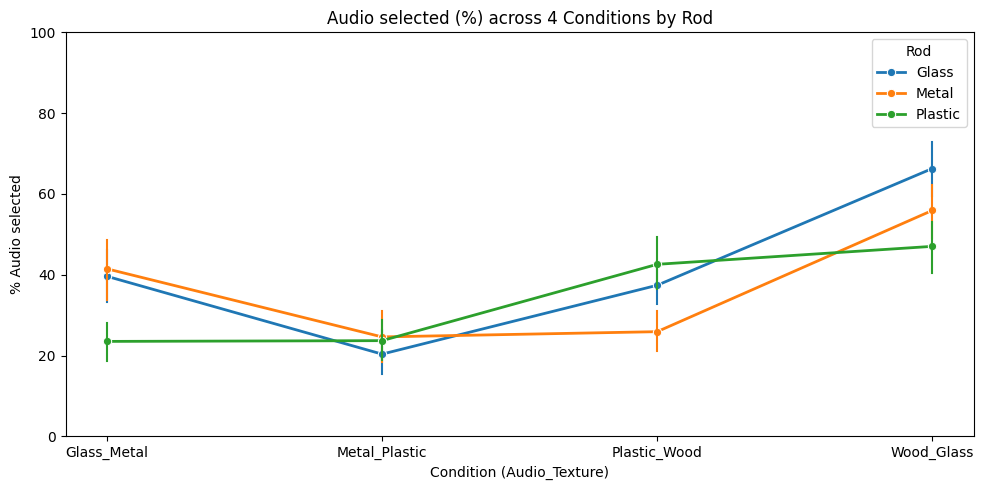

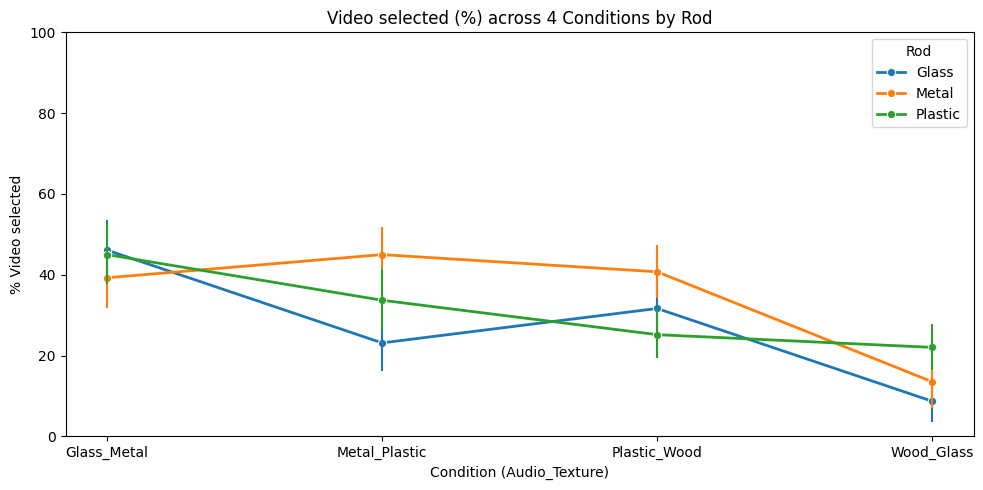

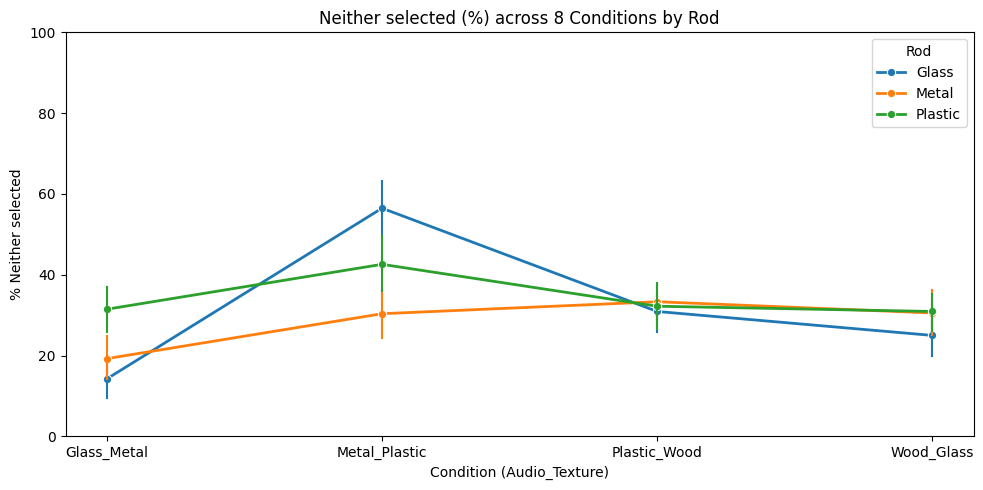

In [ ]:
dfc = df_match2.copy()

dfc["Condition"] = dfc["Audio"].astype(str) + "_" + dfc["Texture"].astype(str)
print(dfc)

df = dfc[dfc["match_type"] == "Matches Audio"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Audio selected (%) across 4 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Audio selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Audio across conditions per rod.png', bbox_inches='tight')
plt.show()


df = dfc[dfc["match_type"] == "Matches Video"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Video selected (%) across 4 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Video selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Video across conditions per rod.png', bbox_inches='tight')
plt.show()

df = dfc[dfc["match_type"] == "Matches Neither"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Rod",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Neither selected (%) across 8 Conditions by Rod")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Neither selected")
plt.ylim(0, 100)
plt.legend(title="Rod")
plt.tight_layout()
plt.savefig('%Neither across conditions per rod.png', bbox_inches='tight')
plt.show()

     Participant_ID      Rod Noise          Order Texture  Audio  \
0               Mel    Glass    NN  Starts with N   Metal  Glass   
1               Mel    Glass    NN  Starts with N   Metal  Glass   
2               Mel    Glass    NN  Starts with N   Metal  Glass   
3              Kian    Glass    NN  Starts with N   Metal  Glass   
4              Kian    Glass    NN  Starts with N   Metal  Glass   
...             ...      ...   ...            ...     ...    ...   
1939           Alis  Plastic    MN  Starts with M   Glass   Wood   
1940           Alis  Plastic    MN  Starts with M   Glass   Wood   
1941           Josh  Plastic    MN  Starts with M   Glass   Wood   
1942           Josh  Plastic    MN  Starts with M   Glass   Wood   
1943           Josh  Plastic    MN  Starts with M   Glass   Wood   

           match_type  match_freq  pct_match    Condition  
0       Matches Audio           9       90.0  Glass_Metal  
1       Matches Video           1       10.0  Glass_Metal  
2  

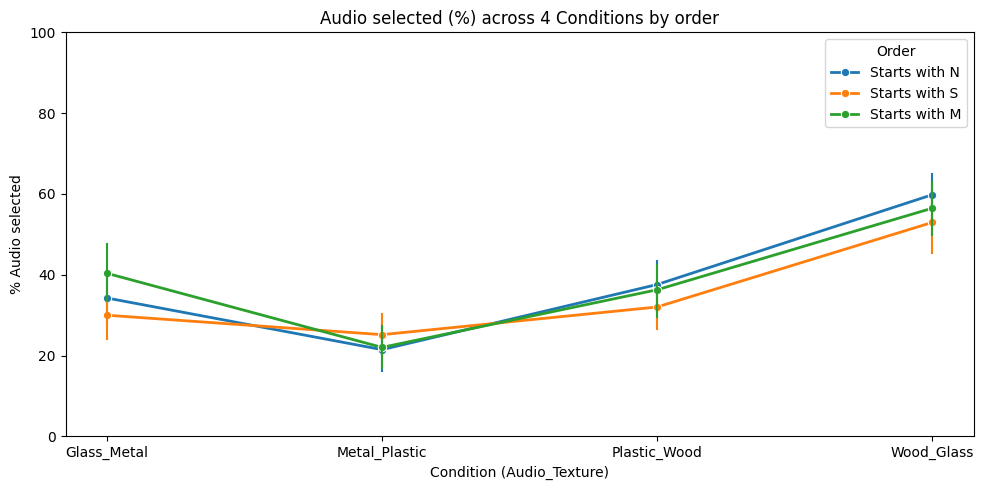

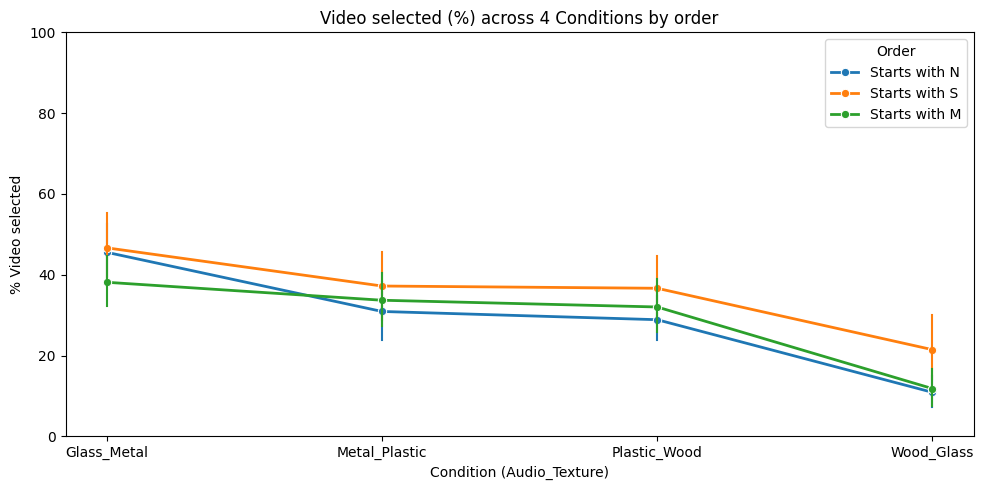

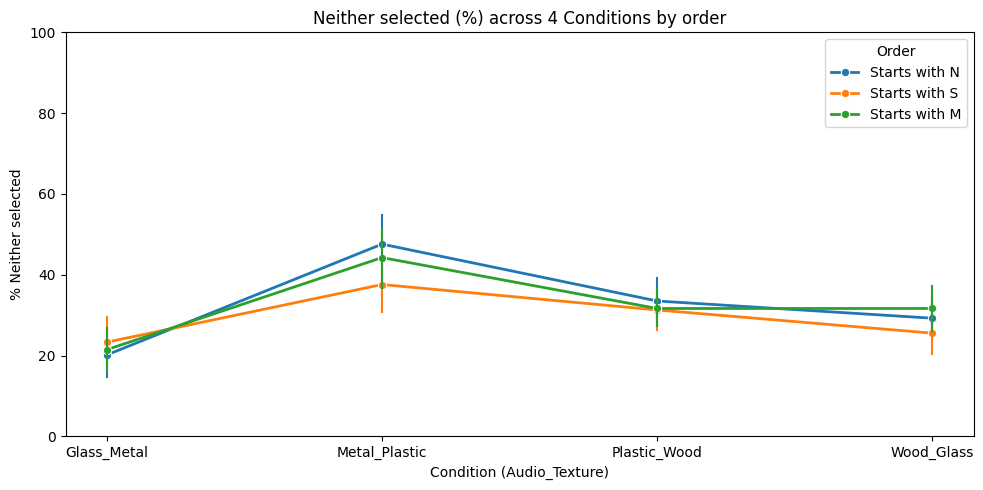

In [ ]:
dfc = df_match2.copy()

dfc["Condition"] = dfc["Audio"].astype(str) + "_" + dfc["Texture"].astype(str)
print(dfc)

df = dfc[dfc["match_type"] == "Matches Audio"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Order",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Audio selected (%) across 4 Conditions by order")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Audio selected")
plt.ylim(0, 100)
plt.legend(title="Order")
plt.tight_layout()
plt.savefig('%Audio across conditions per order.png', bbox_inches='tight')
plt.show()

df = dfc[dfc["match_type"] == "Matches Video"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Order",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Video selected (%) across 4 Conditions by order")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Video selected")
plt.ylim(0, 100)
plt.legend(title="Order")
plt.tight_layout()
plt.savefig('%Video across conditions per order.png', bbox_inches='tight')
plt.show()

df = dfc[dfc["match_type"] == "Matches Neither"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Order",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Neither selected (%) across 4 Conditions by order")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Neither selected")
plt.ylim(0, 100)
plt.legend(title="Order")
plt.tight_layout()
plt.savefig('%Neither across conditions per order.png', bbox_inches='tight')
plt.show()


     Participant_ID      Rod Noise          Order Texture  Audio  \
0               Mel    Glass    NN  Starts with N   Metal  Glass   
1               Mel    Glass    NN  Starts with N   Metal  Glass   
2               Mel    Glass    NN  Starts with N   Metal  Glass   
3              Kian    Glass    NN  Starts with N   Metal  Glass   
4              Kian    Glass    NN  Starts with N   Metal  Glass   
...             ...      ...   ...            ...     ...    ...   
1939           Alis  Plastic    MN  Starts with M   Glass   Wood   
1940           Alis  Plastic    MN  Starts with M   Glass   Wood   
1941           Josh  Plastic    MN  Starts with M   Glass   Wood   
1942           Josh  Plastic    MN  Starts with M   Glass   Wood   
1943           Josh  Plastic    MN  Starts with M   Glass   Wood   

           match_type  match_freq  pct_match    Condition  
0       Matches Audio           9       90.0  Glass_Metal  
1       Matches Video           1       10.0  Glass_Metal  
2  

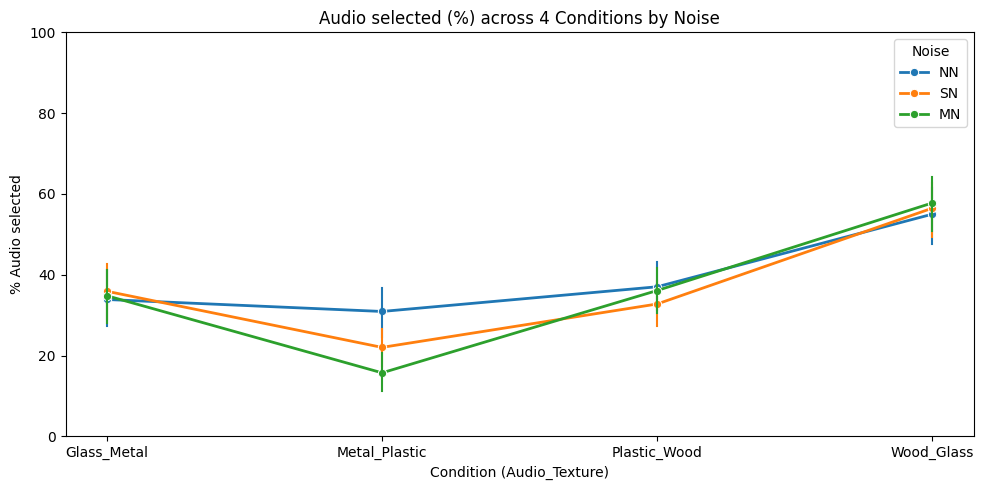

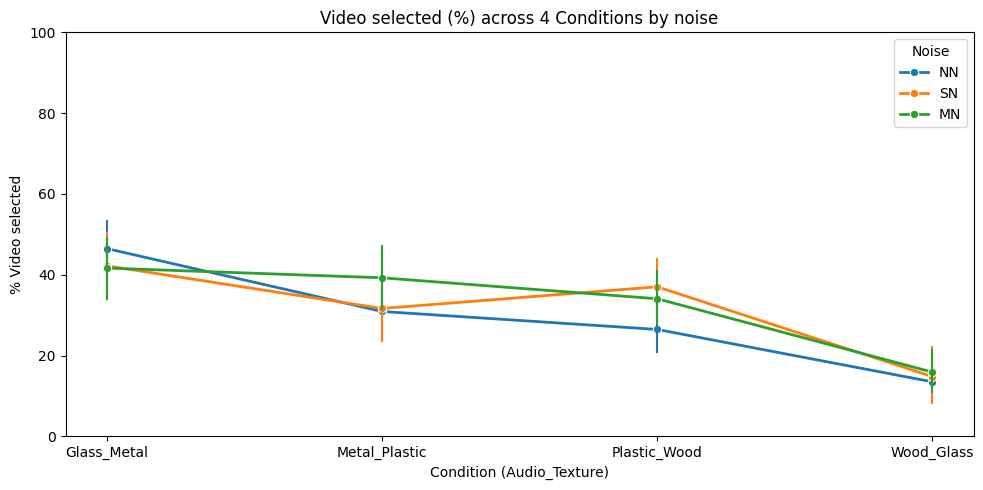

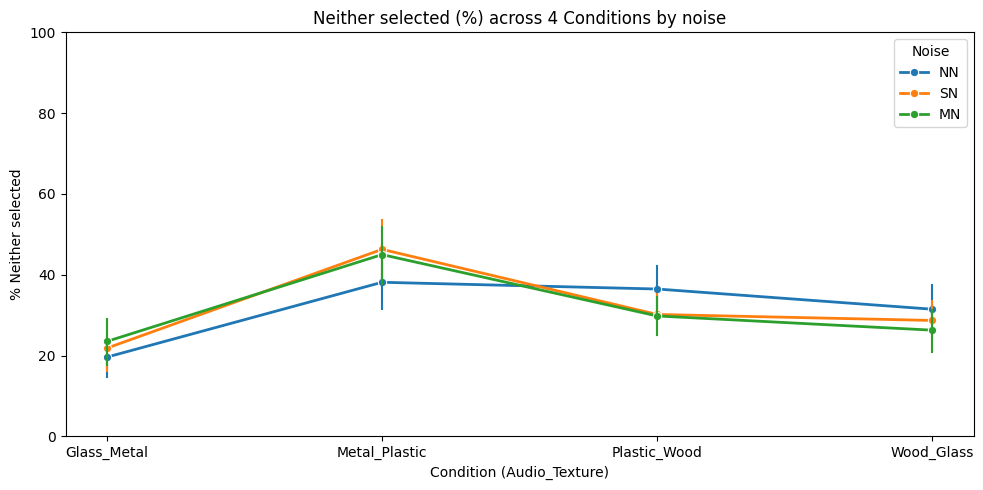

In [ ]:
dfc = df_match2.copy()

dfc["Condition"] = dfc["Audio"].astype(str) + "_" + dfc["Texture"].astype(str)
print(dfc)

df = dfc[dfc["match_type"] == "Matches Audio"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Noise",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Audio selected (%) across 4 Conditions by Noise")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Audio selected")
plt.ylim(0, 100)
plt.legend(title="Noise")
plt.tight_layout()
plt.savefig('%Audio across conditions per Noise level.png', bbox_inches='tight')
plt.show()

df = dfc[dfc["match_type"] == "Matches Video"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Noise",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Video selected (%) across 4 Conditions by noise")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Video selected")
plt.ylim(0, 100)
plt.legend(title="Noise")
plt.tight_layout()
plt.savefig('%Video across conditions per noise level.png', bbox_inches='tight')
plt.show()

df = dfc[dfc["match_type"] == "Matches Neither"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Condition",
    y="pct_match",
    hue="Noise",       # Each Rod will be its own line
    marker="o",
    err_style="bars",         # No shaded confidence interval
    linewidth=2
)
plt.title("Neither selected (%) across 4 Conditions by noise")
plt.xlabel("Condition (Audio_Texture)")
plt.ylabel("% Neither selected")
plt.ylim(0, 100)
plt.legend(title="Noise")
plt.tight_layout()
plt.savefig('%Neither across conditions per noise level.png', bbox_inches='tight')
plt.show()


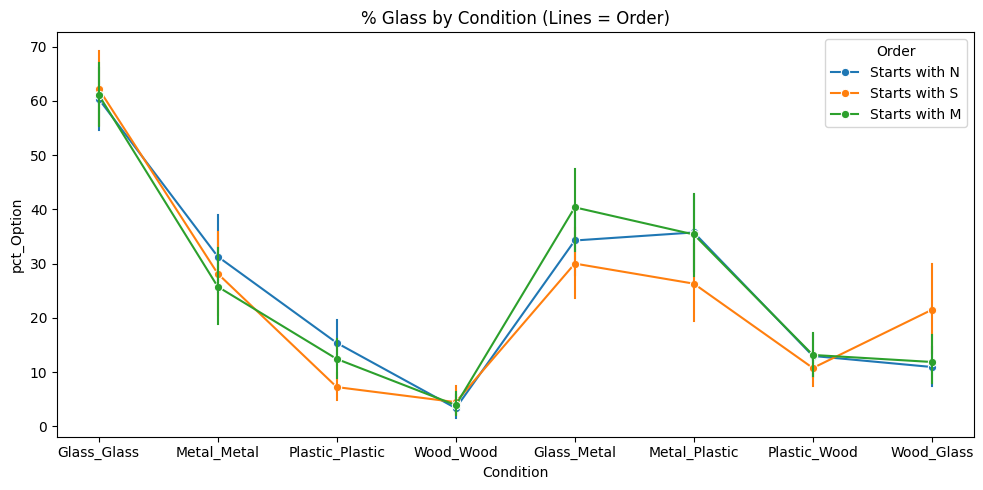

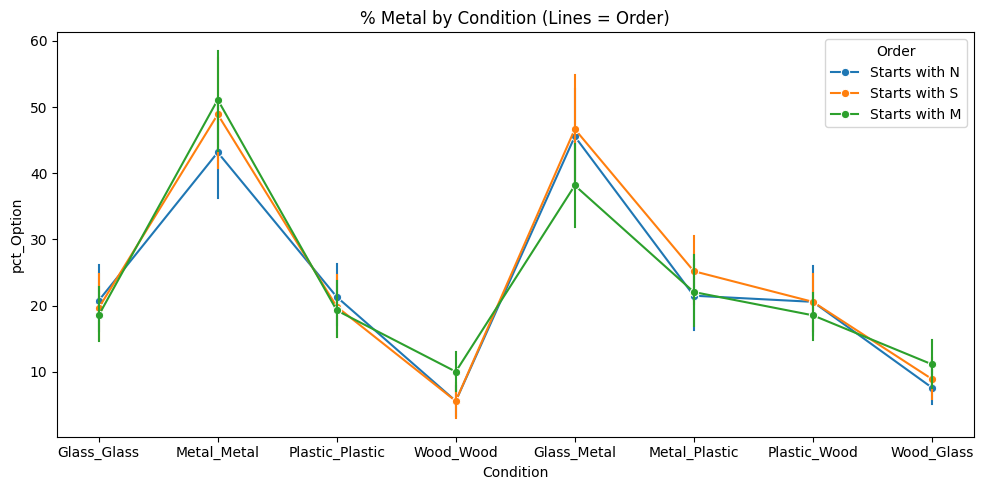

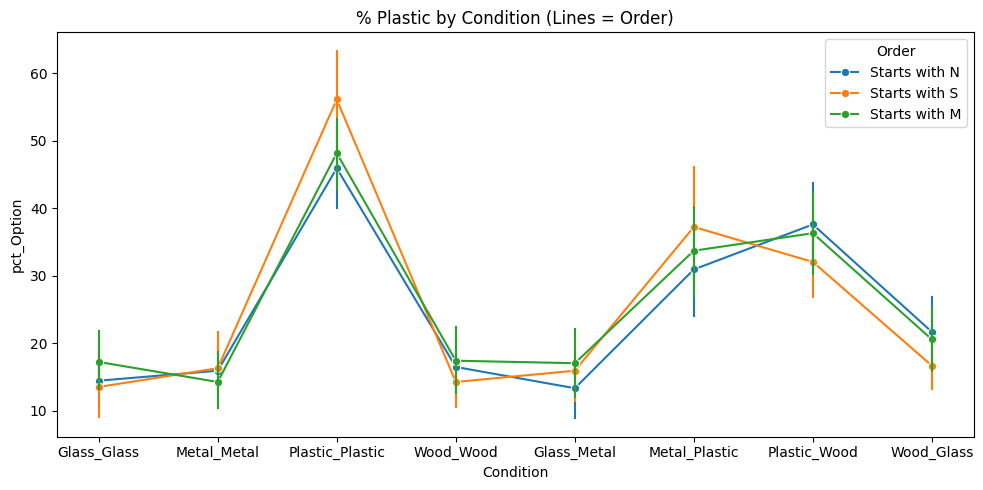

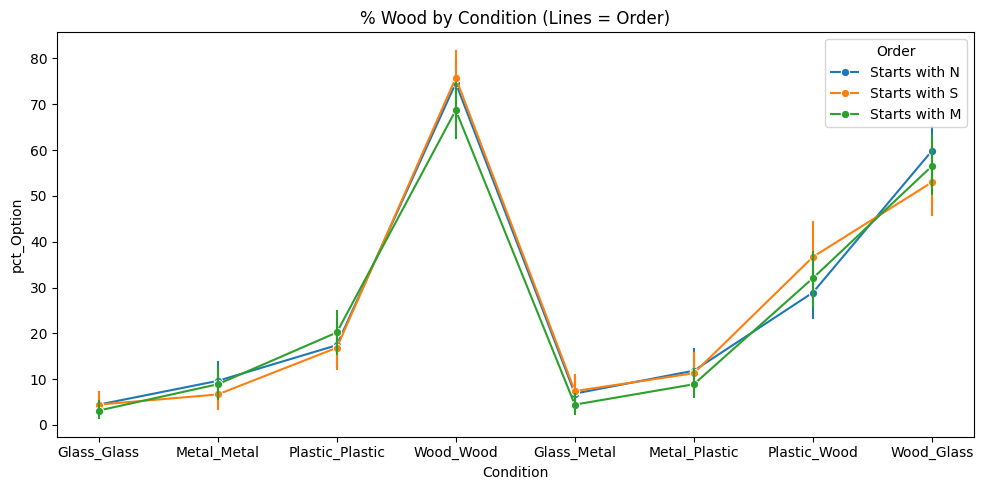

In [ ]:


# Filter for glass only
df = data[data["Option"] == "Glass"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Glass by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Glass across conditions by Order.png', bbox_inches='tight')
plt.show()






df = data[data["Option"] == "Metal"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Metal by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Metal across conditions by Order.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Plastic"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Plastic by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Plastic across conditions by Order.png', bbox_inches='tight')
plt.show()

df = data[data["Option"] == "Wood"].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    y='pct_Option',       # <-- X-axis: percentage glass selected
    x='Condition',       # <-- Y-axis: conditions
    hue='Order',         # <-- Each line = different order
    marker = 'o',
    err_style="bars"
)

plt.title('% Wood by Condition (Lines = Order)')
plt.legend(title='Order')
plt.tight_layout()
plt.savefig('%Wood across conditions by Order.png', bbox_inches='tight')
plt.show()